# Plan G — Protein parameter guide (technical)

Deep reference for the protein visualization project. Audience: a strong CS student who wants **precise field semantics**, FragPipe/IonQuant column contracts, missingness rules, and reproducible pandas pipelines—not a one-line cheat sheet.

**Primary table (omics):** `/data/ganye/Protein_visualization/combined_protein.tsv`

**Join key:** `Protein ID` (UniProt accession). Treat `Gene` as a display label only (ambiguous across organisms in HYE mixtures).

**Scope:** Plan G → **GA.1–GA.6**. Unique peptide counts are intentionally out of scope.

**Related outputs directory:** `/data/ganye/Protein_visualization/`

**Canonical rules already locked in:**
- **GA.2:** adjusted p-value columns come from `combined_protein.tsv` when FragPipe/IonQuant wrote them (pattern `*Adjusted P-value*` / `*Adj. P-value*`).
- **GA.3:** **PDB first**. If no PDB cross-reference exists, the output string is exactly `no pdb avaliable`.

**Plots:** PNG figures under `/data/ganye/Protein_visualization/plots/` (see each GA “How to plot” subsection).


## Plan G — why these six parameters

### Issue
A FragPipe `combined_protein.tsv` is a wide quantification + identification report. A visualization layer also needs structure, sequence, interactions, and localization. Those live partly in the TSV and partly in external databases. Mixing ID-confidence scores with differential statistics, or AlphaFold with PDB, produces wrong joins and wrong UI semantics.

### Solution
Enumerate parameters as **GA.1–GA.6**. For each: define the measurement, name the exact columns/APIs, show pandas load/filter/display, export a tidy CSV under `/data/ganye/Protein_visualization/`, and state caveats (units, missingness, organism ambiguity).

### Progress
- HYE FragPipe table on omics wired as `DATA_PATH` (full file, not a head sample).
- Offline exports complete for MaxLFQ; adj-p columns absent in this particular TSV (documented).
- UniProt-batched PDB / sequence / spatial for all proteins; STRING PPI mapped with organism-aware taxids.


## Setup — load `combined_protein.tsv` with pandas

FragPipe’s Philosopher/IonQuant combiner emits a **tab-separated** protein report. Always use `sep="\t"` (or `pd.read_table`). Prefer `low_memory=False` on wide tables so dtypes don’t flip mid-file (this HYE file has 240 columns; mixed-type warnings appear on trailing columns such as `Indistinguishable Proteins`).

**Important identity columns (always inspect first):**
| Column | Role |
| --- | --- |
| `Protein ID` | UniProt accession — **primary join key** |
| `Protein` / `Entry Name` | longer protein descriptor / UniProt entry name |
| `Gene` | gene symbol (not unique across organisms) |
| `Protein Length` | residue count from the search DB |
| `Organism` | taxonomy string from the FASTA header |
| `Protein Probability` | ProteinProphet **ID confidence** ∈ [0,1] — **not** a DE p-value |
| `Top Peptide Probability` | best peptide-level probability supporting the protein |
| `Combined Total Peptides` / spectral-count aggregates | identification evidence depth |

Per-sample quantification families (FragPipe naming):
- `{{sample}} Spectral Count` / `{{sample}} Unique Spectral Count`
- `{{sample}} Intensity` (summed precursor intensity)
- `{{sample}} MaxLFQ Intensity` (MaxLFQ-normalized abundance; preferred for LFQ proteome profiling)


In [1]:
from pathlib import Path
import pandas as pd

OUT = Path("/data/ganye/Protein_visualization")
DATA_PATH = OUT / "combined_protein.tsv"
assert DATA_PATH.is_file(), DATA_PATH

# Tab-separated FragPipe protein report — full file
df = pd.read_csv(DATA_PATH, sep="\t", low_memory=False)

print("DATA_PATH =", DATA_PATH)
print("shape (rows, cols) =", df.shape)
print("\ndtypes (first 25):")
print(df.dtypes.head(25))
print("\nkey identity + evidence columns:")
key_cols = [
    "Protein ID", "Gene", "Protein Length", "Organism",
    "Protein Probability", "Top Peptide Probability",
    "Combined Total Peptides", "Combined Spectral Count",
]
display_cols = [c for c in key_cols if c in df.columns]
print(display_cols)
df[display_cols].head(10)


DATA_PATH = /data/ganye/Protein_visualization/combined_protein.tsv
shape (rows, cols) = (9369, 240)

dtypes (first 25):
Protein                            object
Protein ID                         object
Entry Name                         object
Gene                               object
Protein Length                      int64
Organism                           object
Protein Existence                  object
Description                        object
Protein Probability               float64
Top Peptide Probability           float64
Combined Total Peptides             int64
Combined Spectral Count             int64
Combined Unique Spectral Count      int64
Combined Total Spectral Count       int64
Condition_A_34 Spectral Count       int64
Condition_A_35 Spectral Count       int64
Condition_A_36 Spectral Count       int64
Condition_A_37 Spectral Count       int64
Condition_A_38 Spectral Count       int64
Condition_A_39 Spectral Count       int64
Condition_A_40 Spectral Count       int6

,Protein ID,Gene,Protein Length,Organism,Protein Probability,Top Peptide Probability,Combined Total Peptides,Combined Spectral Count
0,A0A024R1R8,TMA7B,64,Homo sapiens,0.9516,0.9989,1,34
1,A0A0B4J2F0,PIGBOS1,54,Homo sapiens,0.9504,0.9987,1,13
2,A0A0J9YX57,MAGEB6B,407,Homo sapiens,0.9753,0.9987,1,4
3,A0A2R8Y4L2,HNRNPA1L3,320,Homo sapiens,1.0000,0.9990,17,55
4,A0A7I2V3R4,RNF228,345,Homo sapiens,0.9901,0.9964,1,30
5,A0AVT1,UBA6,1052,Homo sapiens,1.0000,0.9990,49,1320
6,A0FGR8,ESYT2,921,Homo sapiens,1.0000,0.9990,13,108
7,A0JLT2,MED19,244,Homo sapiens,1.0000,0.9990,4,55
8,A0MZ66,SHTN1,631,Homo sapiens,1.0000,0.9990,21,306
9,A1L020,MEX3A,520,Homo sapiens,0.9901,0.9989,2,37


In [2]:
# Explicit column inventory by FragPipe suffix family
cols = list(df.columns)
maxlfq_cols = [c for c in cols if c.endswith(" MaxLFQ Intensity")]
intensity_cols = [c for c in cols if c.endswith(" Intensity") and not c.endswith(" MaxLFQ Intensity")]
spec_cols = [c for c in cols if c.endswith(" Spectral Count")]
unique_spec_cols = [c for c in cols if c.endswith(" Unique Spectral Count")]

def is_adj_p(col: str) -> bool:
    c = col.lower().replace("_", " ")
    return (
        "adjusted p-value" in c
        or "adjusted p value" in c
        or "adj. p-value" in c
        or "adj p-value" in c
        or "adj.p.value" in c
        or bool(re.search(r"\badj\.?\s*p\b", c))
    )

adj_p_cols = [c for c in cols if is_adj_p(c)]
raw_p_cols = [c for c in cols if ("p-value" in c.lower() or "p value" in c.lower()) and c not in adj_p_cols]

print(f"total columns: {len(cols)}")
print(f"MaxLFQ Intensity columns: {len(maxlfq_cols)}")
print(f"raw Intensity columns: {len(intensity_cols)}")
print(f"Spectral Count columns: {len(spec_cols)}")
print(f"Unique Spectral Count columns: {len(unique_spec_cols)}")
print(f"Adjusted P-value columns: {len(adj_p_cols)} -> {adj_p_cols[:10]}")
print(f"other P-value-like columns: {len(raw_p_cols)} -> {raw_p_cols[:10]}")
print("\nFirst 15 MaxLFQ columns:")
print(maxlfq_cols[:15])
print("\nOrganism value counts:")
print(df["Organism"].value_counts().head(10))
pd.DataFrame({
    "family": ["MaxLFQ", "Intensity", "Spectral Count", "Adj P-value"],
    "n_columns": [len(maxlfq_cols), len(intensity_cols), len(spec_cols), len(adj_p_cols)],
})


total columns: 240
MaxLFQ Intensity columns: 45
raw Intensity columns: 45
Spectral Count columns: 138
Unique Spectral Count columns: 46
Adjusted P-value columns: 0 -> []
other P-value-like columns: 0 -> []

First 15 MaxLFQ columns:
['Condition_A_34 MaxLFQ Intensity', 'Condition_A_35 MaxLFQ Intensity', 'Condition_A_36 MaxLFQ Intensity', 'Condition_A_37 MaxLFQ Intensity', 'Condition_A_38 MaxLFQ Intensity', 'Condition_A_39 MaxLFQ Intensity', 'Condition_A_40 MaxLFQ Intensity', 'Condition_A_41 MaxLFQ Intensity', 'Condition_A_42 MaxLFQ Intensity', 'Condition_A_43 MaxLFQ Intensity', 'Condition_A_44 MaxLFQ Intensity', 'Condition_A_45 MaxLFQ Intensity', 'Condition_B_22 MaxLFQ Intensity', 'Condition_B_23 MaxLFQ Intensity', 'Condition_B_24 MaxLFQ Intensity']

Organism value counts:
Organism
Homo sapiens                                             5054
Saccharomyces cerevisiae (strain ATCC 204508 / S288c)    3098
Escherichia coli (strain K12)                            1212
Ovis aries             

,family,n_columns
0,MaxLFQ,45
1,Intensity,45
2,Spectral Count,138
3,Adj P-value,0


## GA — Parameter guide

### Issue
`combined_protein.tsv` mixes (1) identification confidence, (2) per-sample quantification, and optionally (3) comparison statistics. External modalities (PDB, sequence, STRING, UniProt locations) share only the accession namespace. Without an explicit inventory, viewers bind the wrong column (e.g. treating `Protein Probability` as a differential FDR).

### Solution
For each GA item below: load with pandas → list the **exact** columns → show `head`/`shape` → write or reload the section CSV.

### Progress / inventory (this HYE file)

| Parameter | In this TSV? | Where / pattern |
| --- | --- | --- |
| MaxLFQ abundance | Yes | `{sample} MaxLFQ Intensity` (45 samples here) |
| Adjusted p-value | **No columns in this file** | When present: `*Adjusted P-value*` / `*Adj. P-value*` (comparison-prefixed). Still distinct from `Protein Probability`. |
| Structure | No | PDB via UniProt `xref_pdb`; else `no pdb avaliable` |
| Sequence | Length only | UniProt sequence; compare to `Protein Length` |
| PPI | No | STRING (organism-aware taxid) |
| Spatial mapping | No | UniProt `SUBCELLULAR LOCATION` + HPA URL |

**Missingness gotcha (MaxLFQ):** IonQuant often stores nondetects as numeric `0`, not NaN. For log-scales and stats, map `0 → NA` unless you have confirmed zeros are real.


### GA.1 — MaxLFQ intensity (abundance)

#### What it is
**MaxLFQ** (Cox et al.; implemented in IonQuant for FragPipe LFQ) is a delayed-normalization estimate of protein abundance across runs. Column contract in `combined_protein.tsv`:

```text
{experiment_or_sample_name} MaxLFQ Intensity
```

Example from this file: `Condition_A_34 MaxLFQ Intensity`, `Yeast_1 MaxLFQ Intensity`, `QC_10 MaxLFQ Intensity`.

**Scale / units:** dimensionless instrument-derived intensity after MaxLFQ normalization—**not** moles or copies/cell. Values span many orders of magnitude; analyses almost always use `log2` or `log10` of positive intensities.

**Related but different columns:**
- `{sample} Intensity` — summed ion intensity (IonQuant “top N” style sum); often preferred for AP-MS bait-vs-control, while MaxLFQ is preferred for deep proteome profiling.
- Spectral counts — discrete evidence counts; poorer dynamic range for abundance visualization.

#### Missingness
In this HYE extract, roughly ~39% of MaxLFQ matrix entries are `0`. Treat those as missing for log transforms unless you verify otherwise:

```python
mat = df[maxlfq_cols].replace(0, pd.NA)
```

#### Plots
Log-abundance histograms/boxplots per sample; PCA/heatmap on the protein×sample matrix; missingness vs median log-intensity; volcano after pairing with adj-p / log2FC (GA.2).


In [3]:
# GA.1 — list MaxLFQ columns, show matrix head, write / reload full CSVs
maxlfq_cols = [c for c in df.columns if c.endswith(" MaxLFQ Intensity")]
print(f"n MaxLFQ columns = {len(maxlfq_cols)}")
print(maxlfq_cols)

wide = df[["Protein ID", "Gene"] + maxlfq_cols].replace(0, pd.NA)
print("\nwide shape:", wide.shape)
print("fraction missing (was 0):", float(wide[maxlfq_cols].isna().mean().mean()))
print("\nwide head (Protein ID + first 5 MaxLFQ cols):")
show = wide[["Protein ID", "Gene"] + maxlfq_cols[:5]]
print(show.dtypes)

wide.to_csv(OUT / "maxlfq_wide.csv", index=False)
long = wide.melt(id_vars=["Protein ID", "Gene"], var_name="sample", value_name="MaxLFQ")
long["sample"] = long["sample"].str.replace(" MaxLFQ Intensity", "", regex=False)
long["log10_MaxLFQ"] = long["MaxLFQ"].map(lambda x: math.log10(x) if pd.notna(x) and x > 0 else pd.NA)
long.to_csv(OUT / "maxlfq_long.csv", index=False)
print("wrote", OUT / "maxlfq_wide.csv", "rows", len(wide))
print("wrote", OUT / "maxlfq_long.csv", "rows", len(long))

re_wide = pd.read_csv(OUT / "maxlfq_wide.csv", low_memory=False)
re_long = pd.read_csv(OUT / "maxlfq_long.csv", low_memory=False)
print("reloaded wide", re_wide.shape, "long", re_long.shape)
show.head(8)


n MaxLFQ columns = 45
['Condition_A_34 MaxLFQ Intensity', 'Condition_A_35 MaxLFQ Intensity', 'Condition_A_36 MaxLFQ Intensity', 'Condition_A_37 MaxLFQ Intensity', 'Condition_A_38 MaxLFQ Intensity', 'Condition_A_39 MaxLFQ Intensity', 'Condition_A_40 MaxLFQ Intensity', 'Condition_A_41 MaxLFQ Intensity', 'Condition_A_42 MaxLFQ Intensity', 'Condition_A_43 MaxLFQ Intensity', 'Condition_A_44 MaxLFQ Intensity', 'Condition_A_45 MaxLFQ Intensity', 'Condition_B_22 MaxLFQ Intensity', 'Condition_B_23 MaxLFQ Intensity', 'Condition_B_24 MaxLFQ Intensity', 'Condition_B_25 MaxLFQ Intensity', 'Condition_B_26 MaxLFQ Intensity', 'Condition_B_27 MaxLFQ Intensity', 'Condition_B_28 MaxLFQ Intensity', 'Condition_B_29 MaxLFQ Intensity', 'Condition_B_30 MaxLFQ Intensity', 'Condition_B_31 MaxLFQ Intensity', 'Condition_B_32 MaxLFQ Intensity', 'Condition_B_33 MaxLFQ Intensity', 'Ecoli_19 MaxLFQ Intensity', 'Ecoli_20 MaxLFQ Intensity', 'Ecoli_21 MaxLFQ Intensity', 'Human_4 MaxLFQ Intensity', 'Human_5 MaxLFQ Intens

,Protein ID,Gene,Condition_A_34 MaxLFQ Intensity,Condition_A_35 MaxLFQ Intensity,Condition_A_36 MaxLFQ Intensity,Condition_A_37 MaxLFQ Intensity,Condition_A_38 MaxLFQ Intensity
0,A0A024R1R8,TMA7B,44630560.0,<NA>,45529444.0,41219696.0,39432464.0
1,A0A0B4J2F0,PIGBOS1,<NA>,<NA>,<NA>,<NA>,<NA>
2,A0A0J9YX57,MAGEB6B,<NA>,<NA>,<NA>,<NA>,<NA>
3,A0A2R8Y4L2,HNRNPA1L3,56259456.0,24322842.0,50600504.0,24437934.0,27308164.0
4,A0A7I2V3R4,RNF228,32204710.0,24929654.0,32882852.0,25400292.0,24402856.0
5,A0AVT1,UBA6,110379040.0,115159704.0,112134830.0,110520824.0,110185656.0
6,A0FGR8,ESYT2,11474345.0,7867214.0,9348043.0,7975660.0,7422386.5
7,A0JLT2,MED19,19653398.0,9681011.0,14565072.0,5522995.5,8007069.0


#### How to plot GA.1 from the CSVs

**Load:** `maxlfq_long.csv` (`Protein ID`, `Gene`, `sample`, `MaxLFQ`, `log10_MaxLFQ`) and/or `maxlfq_wide.csv`.

**Transforms:** zeros were already mapped to NA when exporting; use `log10_MaxLFQ` (or `np.log10(MaxLFQ)` on positive values only). Never log raw zeros.

**Figures (saved under `plots/`):**
1. Histogram of `log10_MaxLFQ` — overall dynamic range.
2. Per-sample missingness from `maxlfq_wide` — `isna().mean()` across MaxLFQ columns.
3. Boxplots of `log10_MaxLFQ` by `sample` (subset samples if many).


GA.1 plots from maxlfq_long.csv / maxlfq_wide.csv\n


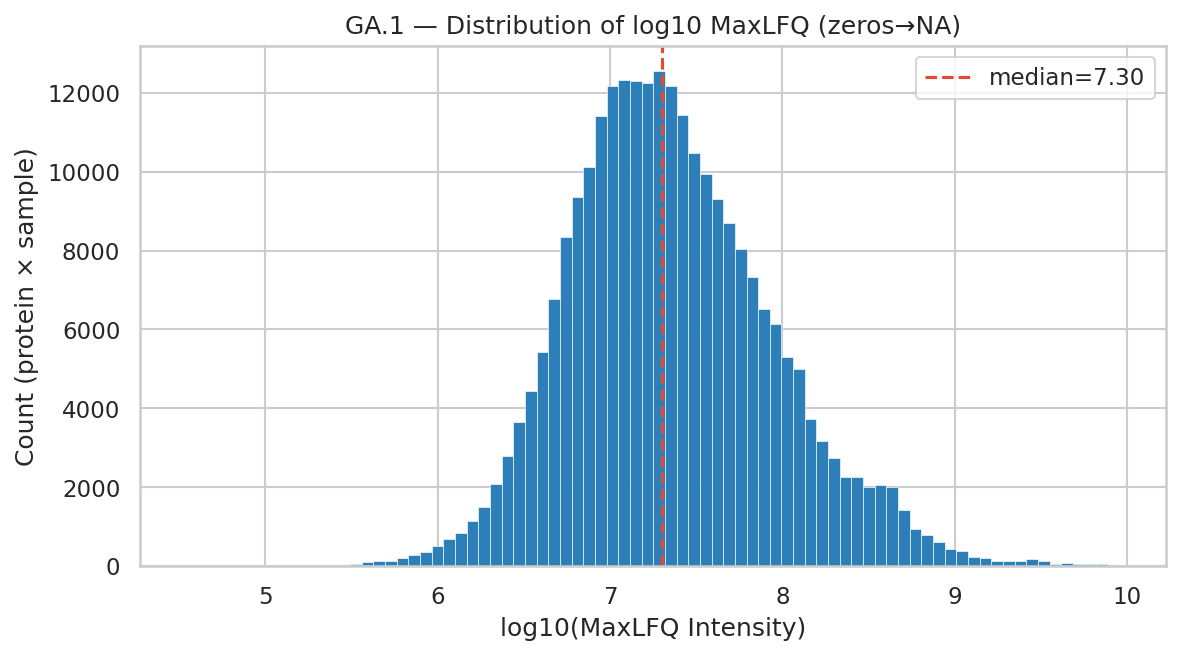

saved /data/ganye/Protein_visualization/plots/ga1_maxlfq_log10_hist.png


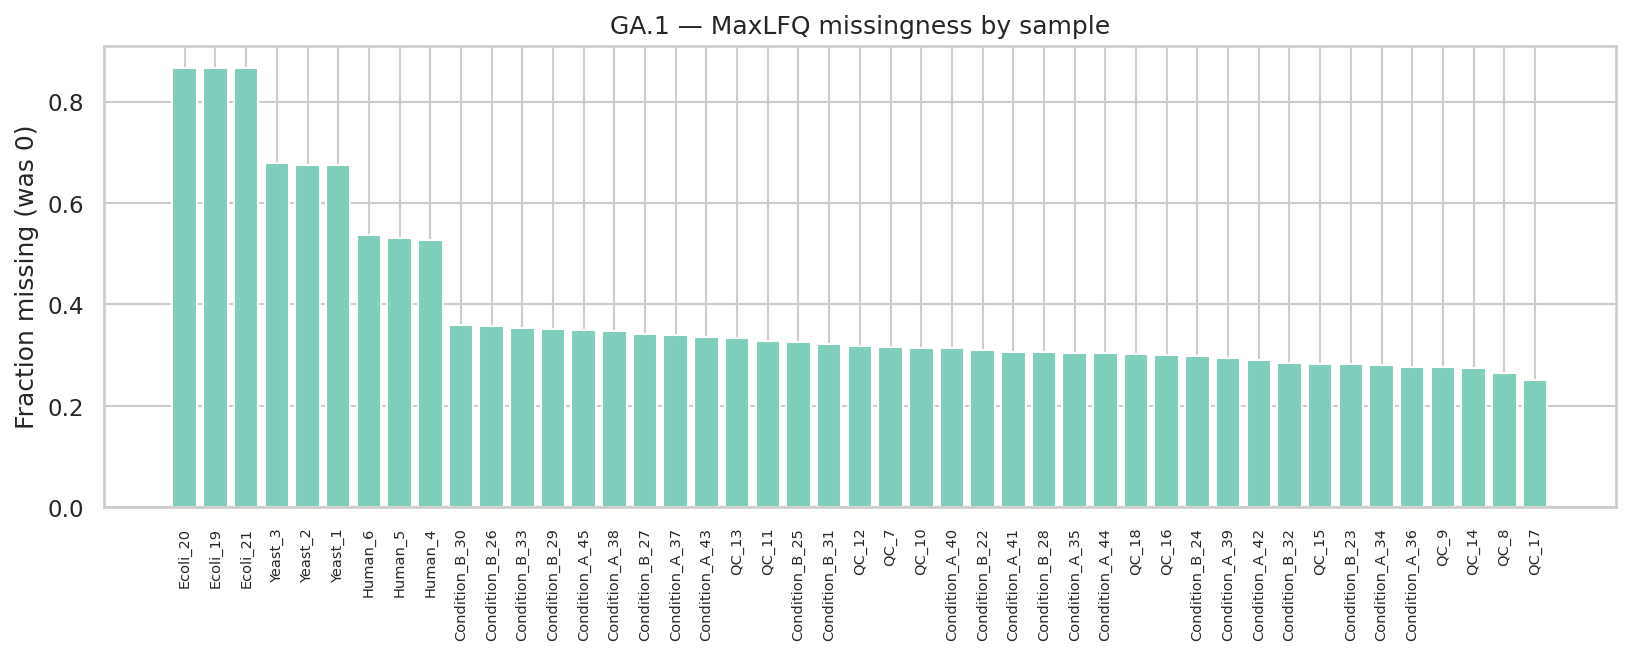

saved /data/ganye/Protein_visualization/plots/ga1_maxlfq_missingness_by_sample.png


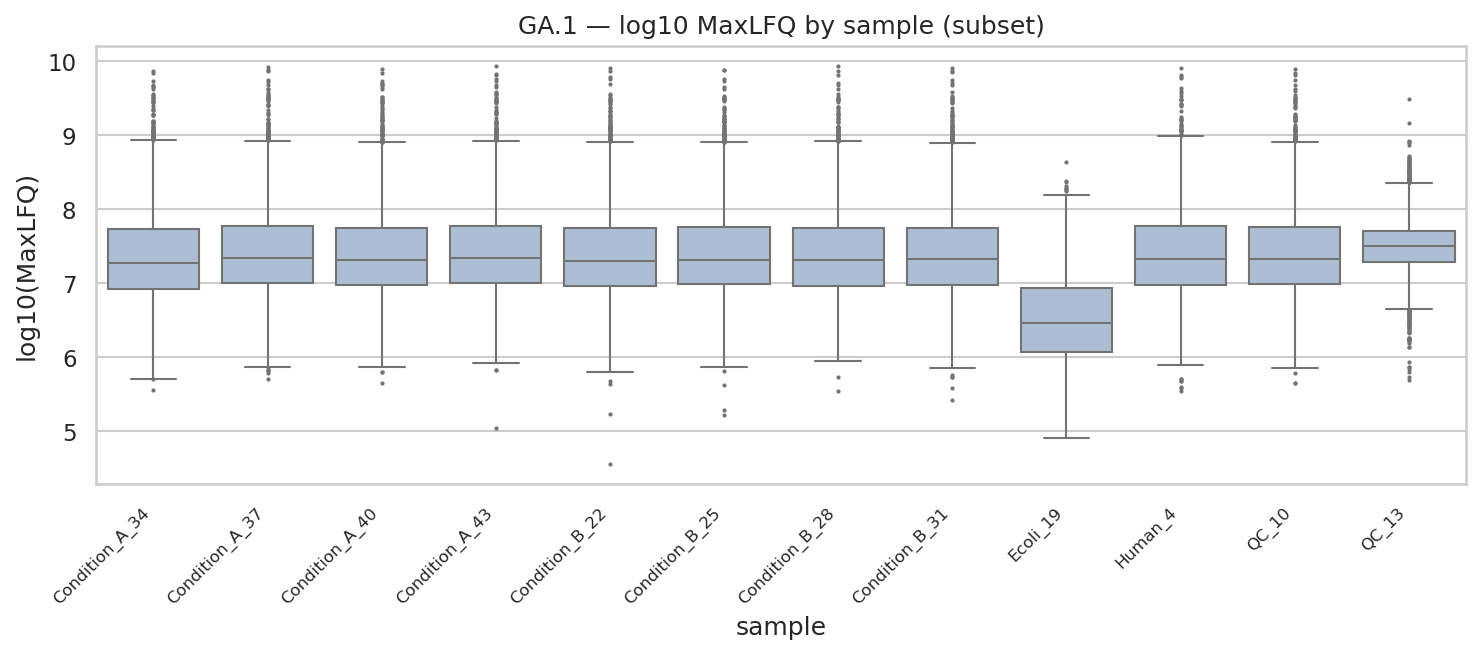

saved /data/ganye/Protein_visualization/plots/ga1_maxlfq_boxplot_samples.png


In [21]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

OUT = Path("/data/ganye/Protein_visualization")
PLOTS = OUT / "plots"
PLOTS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")

long = pd.read_csv(OUT / "maxlfq_long.csv", low_memory=False)
wide = pd.read_csv(OUT / "maxlfq_wide.csv", low_memory=False)
print("long", long.shape, list(long.columns))
print(long.head())

# 1) histogram
fig, ax = plt.subplots(figsize=(8, 4.5))
vals = long["log10_MaxLFQ"].dropna()
ax.hist(vals, bins=80, color="#2c7fb8", edgecolor="white", linewidth=0.3)
ax.set_xlabel("log10(MaxLFQ Intensity)"); ax.set_ylabel("Count")
ax.set_title("GA.1 — log10 MaxLFQ distribution")
fig.savefig(PLOTS / "ga1_maxlfq_log10_hist.png", dpi=150, bbox_inches="tight"); plt.show()

# 2) missingness
maxlfq_cols = [c for c in wide.columns if c.endswith(" MaxLFQ Intensity")]
miss = wide[maxlfq_cols].isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(range(len(miss)), miss.values, color="#7fcdbb")
ax.set_xticks(range(len(miss)))
ax.set_xticklabels([c.replace(" MaxLFQ Intensity","") for c in miss.index], rotation=90, fontsize=7)
ax.set_ylabel("Fraction missing"); ax.set_title("GA.1 — missingness by sample")
fig.savefig(PLOTS / "ga1_maxlfq_missingness_by_sample.png", dpi=150, bbox_inches="tight"); plt.show()

# 3) boxplot subset
samples = sorted(long["sample"].unique())
pick = samples[::max(1, len(samples)//12)][:12]
sub = long[long["sample"].isin(pick)].dropna(subset=["log10_MaxLFQ"])
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=sub, x="sample", y="log10_MaxLFQ", ax=ax, color="#a6bddb", fliersize=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_title("GA.1 — log10 MaxLFQ by sample")
fig.savefig(PLOTS / "ga1_maxlfq_boxplot_samples.png", dpi=150, bbox_inches="tight"); plt.show()


### GA.2 — Adjusted p-value & FragPipe-style volcano (Human vs QC)

#### Issue
Differential significance for visualization must come from a **defined contrast**, not from `Protein Probability` (ID confidence). FragPipe writes optional `*Adjusted P-value*` columns into `combined_protein.tsv` when IonQuant/comparison stats are enabled; this HYE report has **none**. FragPipe-Analyst’s documented DE path is: annotation-driven conditions → MaxLFQ → log2 → **limma** moderated t-tests → BH adj-p → volcano (`log2FC` vs `-log10(p)` or `-log10(adj-p)`).

#### Solution (this notebook)
1. Load `/data/ganye/Protein_visualization/experiment_annotation.tsv` (`file`, `sample`, `sample_name`, `condition`, `replicate`).
2. Map `sample` → FragPipe MaxLFQ columns `{sample} MaxLFQ Intensity`.
3. Restrict to **`condition == "Human"`** vs **`condition == "QC"`** (3 Human + 12 QC replicates in this annotation).
4. Because the TSV lacks adj-p/FC columns for that contrast, compute them with **limma `eBayes` + BH** (same engine FragPipe-Analyst uses), contrast **Human − QC**.
5. Export `ga2_human_vs_qc_limma.csv` and plot volcanoes under `plots/`.

#### Progress
- Annotation path: `/data/ganye/Protein_visualization/experiment_annotation.tsv`
- Result table: `/data/ganye/Protein_visualization/ga2_human_vs_qc_limma.csv`
- Proteins plotted: **4375** (required ≥2 finite MaxLFQ values in each group after 0→NA)
- Volcano PNGs: `ga2_volcano_human_vs_qc_pvalue.png`, `ga2_volcano_human_vs_qc_adj_p.png`
- Highlight cutoffs (FragPipe-Analyst-like defaults): `|log2FC| > 0.7` and `adj_p < 0.05`

#### Technical notes
- **Quant:** MaxLFQ Intensity (LFQ proteome default in FragPipe-Analyst docs).
- **Missingness:** zeros → NA before log2; remaining NAs within kept proteins imputed as `min(finite) − 1` on the log2 scale (≈ half-min intensity), matching common LFQ practice when a full FragPipe-Analyst imputer isn’t selected.
- **Design:** `~ 0 + condition` with levels `QC`, `Human`; contrast `Human - QC`.
- **Y-axis options:** raw limma `p_value` or BH `adj_p` (toggle in FragPipe-Analyst UI; we save both figures).


In [30]:
from pathlib import Path
import pandas as pd

OUT = Path("/data/ganye/Protein_visualization")
ANN_PATH = OUT / "experiment_annotation.tsv"
TSV_PATH = OUT / "combined_protein.tsv"
assert ANN_PATH.is_file() and TSV_PATH.is_file()

ann = pd.read_csv(ANN_PATH, sep="\t")
df = pd.read_csv(TSV_PATH, sep="\t", low_memory=False)
print("experiment_annotation.tsv", ann.shape)
print("columns:", list(ann.columns))
print(ann.dtypes)
print("\ncondition value counts:\n", ann["condition"].value_counts())
print("\nHuman / QC rows:")
print(ann[ann["condition"].isin(["Human", "QC"])][["sample", "sample_name", "condition", "replicate"]].to_string(index=False))

# Map annotation sample → MaxLFQ columns
human_samples = ann.loc[ann["condition"] == "Human", "sample"].astype(str).tolist()
qc_samples = ann.loc[ann["condition"] == "QC", "sample"].astype(str).tolist()
human_cols = [f"{s} MaxLFQ Intensity" for s in human_samples]
qc_cols = [f"{s} MaxLFQ Intensity" for s in qc_samples]
print("\nHuman MaxLFQ cols:", human_cols)
print("QC MaxLFQ cols:", qc_cols)
assert all(c in df.columns for c in human_cols + qc_cols)

# TSV-native adj-p / FC for this contrast? (none expected in this HYE file)
def is_adj_p(col: str) -> bool:
    c = col.lower().replace("_", " ")
    return "adjusted p-value" in c or "adj. p-value" in c or "adj.p.value" in c

adj_cols = [c for c in df.columns if is_adj_p(c)]
print("\nAdjusted P-value columns in TSV:", adj_cols)

# Load limma result produced by FragPipe-Analyst-style R script
de = pd.read_csv(OUT / "ga2_human_vs_qc_limma.csv")
print("\nga2_human_vs_qc_limma.csv", de.shape)
print(de.dtypes)
print(de.head(8))
print("n proteins plotted:", len(de))
print("n sig (adj_p<0.05 & |log2FC|>0.7):", int(((de["adj_p"] < 0.05) & (de["log2FC"].abs() > 0.7)).sum()))
de.head(8)


experiment_annotation.tsv (45, 5)
columns: ['file', 'sample', 'sample_name', 'condition', 'replicate']
file           object
sample         object
sample_name    object
condition      object
replicate       int64
dtype: object

condition value counts:
 condition
Condition    24
QC           12
Ecoli         3
Human         3
Yeast         3
Name: count, dtype: int64

Human / QC rows:
 sample sample_name condition  replicate
Human_4     Human_4     Human          4
Human_5     Human_5     Human          5
Human_6     Human_6     Human          6
  QC_10       QC_10        QC         10
  QC_11       QC_11        QC         11
  QC_12       QC_12        QC         12
  QC_13       QC_13        QC         13
  QC_14       QC_14        QC         14
  QC_15       QC_15        QC         15
  QC_16       QC_16        QC         16
  QC_17       QC_17        QC         17
  QC_18       QC_18        QC         18
   QC_7        QC_7        QC          7
   QC_8        QC_8        QC          

,Protein ID,Gene,log2FC,AveExpr,t,p_value,adj_p,B,contrast,method
0,P32610,VMA8,-2.011673,24.955187,-20.978436,2.720469e-12,1.190205e-08,16.840994,Human_vs_QC,limma_eBayes_BH
1,P35207,SKI2,-6.134601,25.060294,-16.127182,1.079685e-10,2.361810e-07,14.112411,Human_vs_QC,limma_eBayes_BH
2,P0A6Y8,dnaK,-2.473741,25.418634,-14.676737,3.953762e-10,5.765903e-07,13.057758,Human_vs_QC,limma_eBayes_BH
3,P00498,HIS1,-3.480047,24.684964,-12.979544,2.101222e-09,2.298212e-06,11.640200,Human_vs_QC,limma_eBayes_BH
4,P43583,BLM10,-2.487928,23.768858,-12.368877,4.013387e-09,3.511713e-06,11.074652,Human_vs_QC,limma_eBayes_BH
5,P00925,ENO2,-9.723345,29.376445,-11.730685,8.126628e-09,5.925667e-06,10.448612,Human_vs_QC,limma_eBayes_BH
6,P0CE47,tufA,-4.136701,27.240348,-10.857697,2.248687e-08,1.270437e-05,9.529476,Human_vs_QC,limma_eBayes_BH
7,P0A853,tnaA,-5.559540,28.079813,-10.830666,2.323084e-08,1.270437e-05,9.499789,Human_vs_QC,limma_eBayes_BH


#### How to make the Human vs QC volcano from generated files

**Inputs**
1. `/data/ganye/Protein_visualization/experiment_annotation.tsv` — maps `sample` → `condition` (`Human` / `QC`).
2. `/data/ganye/Protein_visualization/combined_protein.tsv` — MaxLFQ columns `{sample} MaxLFQ Intensity` (no adj-p columns in this file).
3. `/data/ganye/Protein_visualization/ga2_human_vs_qc_limma.csv` — limma results: `Protein ID`, `Gene`, `log2FC`, `p_value`, `adj_p`, …

**Reproduce DE (FragPipe-Analyst engine)** — see `/tmp/ga2_limma_human_qc.R` or re-run limma: design `~0+condition`, contrast `Human-QC`, `eBayes`, BH.

**Plot from the CSV alone**

```python
import numpy as np, pandas as pd, matplotlib.pyplot as plt
de = pd.read_csv("ga2_human_vs_qc_limma.csv")
y = -np.log10(de["adj_p"].clip(lower=1e-300))  # or de["p_value"]
sig = (de["adj_p"] < 0.05) & (de["log2FC"].abs() > 0.7)
plt.scatter(de.loc[~sig, "log2FC"], y[~sig], s=12, c="#bdbdbd", alpha=0.45)
plt.scatter(de.loc[sig, "log2FC"], y[sig], s=12, c="#e34a33", alpha=0.55)
plt.axhline(-np.log10(0.05), ls="--"); plt.axvline(0.7, ls="--"); plt.axvline(-0.7, ls="--")
plt.xlabel("log2FC (Human − QC)"); plt.ylabel("-log10(adj p)")
```

**Saved figures:** `plots/ga2_volcano_human_vs_qc_pvalue.png`, `plots/ga2_volcano_human_vs_qc_adj_p.png`.


proteins plotted: 4375


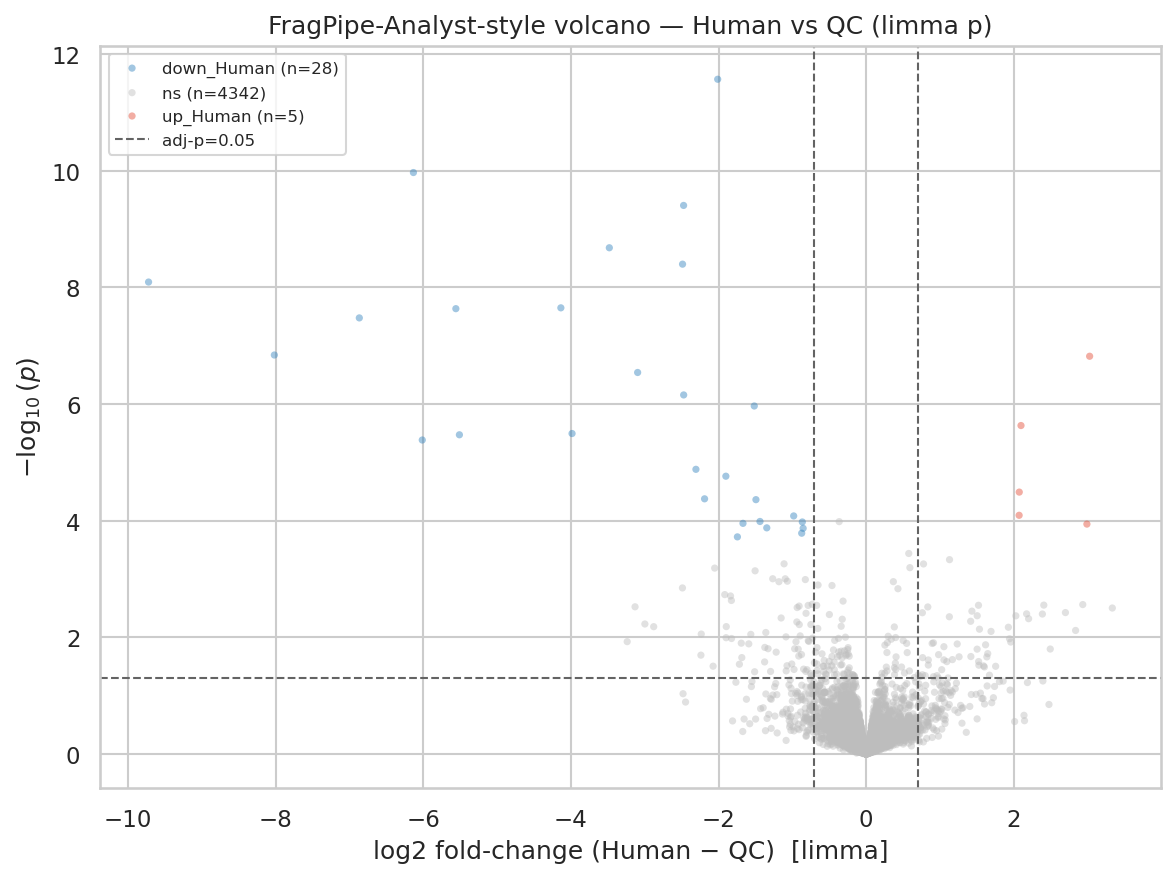

saved ga2_volcano_human_vs_qc_pvalue.png


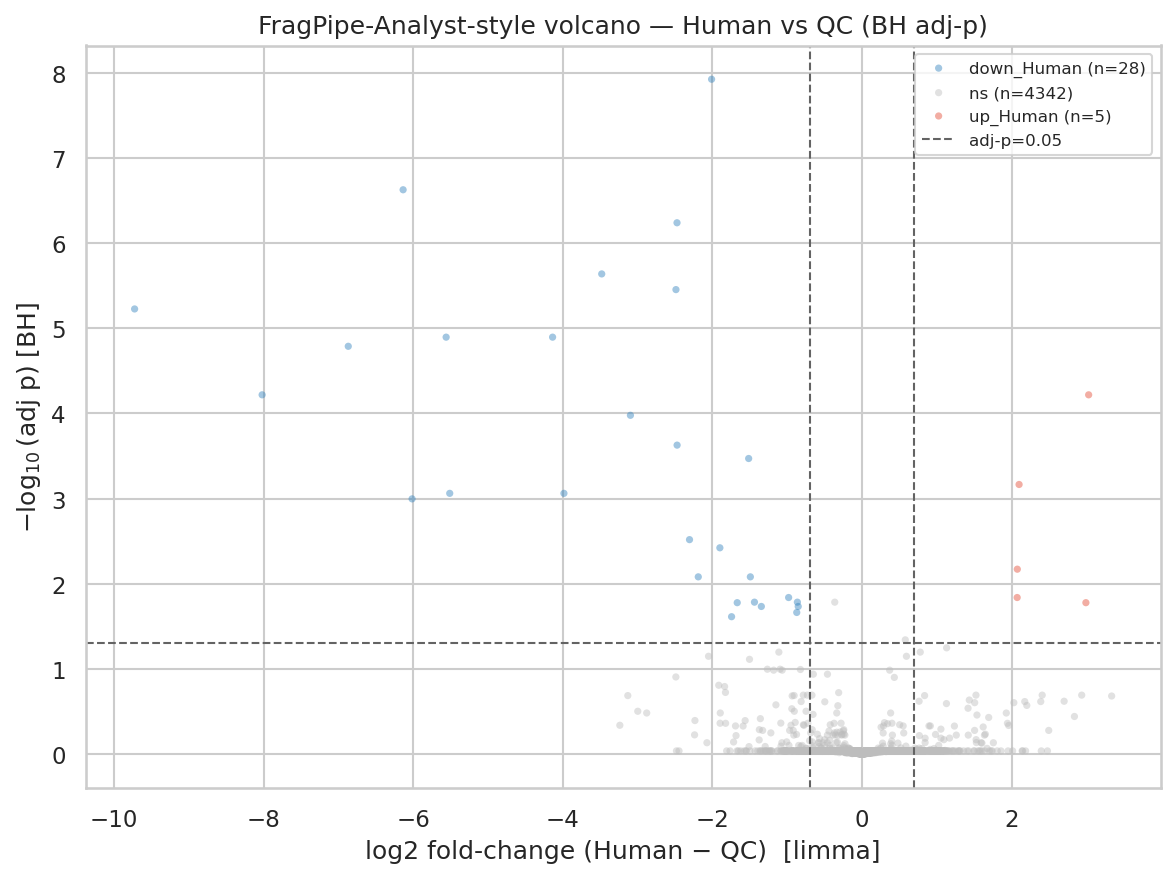

saved ga2_volcano_human_vs_qc_adj_p.png


In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT = Path("/data/ganye/Protein_visualization")
PLOTS = OUT / "plots"
de = pd.read_csv(OUT / "ga2_human_vs_qc_limma.csv")
print("proteins plotted:", len(de))
print(de[["Protein ID", "Gene", "log2FC", "p_value", "adj_p"]].head())

de = de.copy()
de["neglog10_p"] = -np.log10(de["p_value"].clip(lower=1e-300))
de["neglog10_adj_p"] = -np.log10(de["adj_p"].clip(lower=1e-300))
fc_cut, p_cut = 0.7, 0.05
de["sig"] = (de["adj_p"] < p_cut) & (de["log2FC"].abs() > fc_cut)
de["reg"] = np.where(~de["sig"], "ns", np.where(de["log2FC"] > 0, "up_Human", "down_Human"))
colors = {"ns": "#bdbdbd", "up_Human": "#e34a33", "down_Human": "#3182bd"}

def volcano(ycol, ylab, fname, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    for lab, sub in de.groupby("reg"):
        ax.scatter(sub["log2FC"], sub[ycol], s=12, alpha=0.45, c=colors[lab],
                   edgecolors="none", label=f"{lab} (n={len(sub)})")
    ax.axhline(-np.log10(p_cut), ls="--", color="#636363", lw=1)
    ax.axvline(fc_cut, ls="--", color="#636363", lw=1)
    ax.axvline(-fc_cut, ls="--", color="#636363", lw=1)
    ax.set_xlabel("log2 fold-change (Human − QC) [limma]")
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(PLOTS / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print("saved", PLOTS / fname)

volcano("neglog10_p", r"$-\log_{10}(p)$", "ga2_volcano_human_vs_qc_pvalue.png",
        "Human vs QC — limma p (FragPipe-Analyst-style)")
volcano("neglog10_adj_p", r"$-\log_{10}(adj\ p)$ [BH]", "ga2_volcano_human_vs_qc_adj_p.png",
        "Human vs QC — BH adj-p (FragPipe-Analyst-style)")


### GA.3 — Structure (**PDB** primary) + 3D views

#### What it is
Experimental 3D coordinates from the **Protein Data Bank**, linked from UniProt (`database == "PDB"`). **PDB-first** (not AlphaFold). If UniProt lists no PDB xrefs, write exactly `no pdb avaliable` — and **no 3D plot** is produced for those rows.

#### Index CSV
`/data/ganye/Protein_visualization/structure_pdb_index.csv` columns: `Protein ID`, `pdb_id`, `pdb_ids`, `pdb_url`, `status`.

#### 3D rendering pipeline (Biopython + PyMOL)
1. Filter `pdb_id != "no pdb avaliable"`.
2. **Biopython** `PDBList` / RCSB HTTPS → download `/data/ganye/Protein_visualization/pdb_files/pdb{{id}}.ent`.
3. **PyMOL open-source** headless cartoon: orient, then save **front / back / side / top** PNGs under `/data/ganye/Protein_visualization/plots/structure_3d/` as `{pdb_id}_front.png`, etc.
4. Example renders recorded in `ga3_structure_3d_renders.csv`.

**Omics caveat:** `pip install pymol-open-source` works on Python 3.13 here, but importing needs  
`LD_PRELOAD=/usr/lib/x86_64-linux-gnu/libstdc++.so.6` so PyMOL’s `_cmd` finds `GLIBCXX_3.4.30` (Anaconda’s `libstdc++` is too old).

#### Coverage vs 3D
Coverage bar (`ga3_pdb_coverage.png`) summarizes hit vs `no pdb avaliable`. Actual molecular graphics are the multi-view PNGs for selected PDB hits.


In [5]:
from pathlib import Path
import pandas as pd

OUT = Path("/data/ganye/Protein_visualization")
NO_PDB = "no pdb avaliable"
struct = pd.read_csv(OUT / "structure_pdb_index.csv")
print("path:", OUT / "structure_pdb_index.csv")
print("shape:", struct.shape)
print("columns:", list(struct.columns))
print("dtypes:\n", struct.dtypes)
n_hit = int((struct["pdb_id"] != NO_PDB).sum())
n_miss = int((struct["pdb_id"] == NO_PDB).sum())
print(f"PDB hit = {n_hit} | {NO_PDB!r} = {n_miss}")
print("\nexample hits:")
print(struct[struct["pdb_id"] != NO_PDB].head(5))
print("\nexample misses (no 3D plot):")
print(struct[struct["pdb_id"] == NO_PDB].head(5))
renders = pd.read_csv(OUT / "ga3_structure_3d_renders.csv")
print("\n3D example renders:")
print(renders)
struct.head(10)



path: /data/ganye/Protein_visualization/structure_pdb_index.csv
shape: (9369, 5)
columns: ['Protein ID', 'pdb_id', 'pdb_ids', 'pdb_url', 'status']
dtypes:
 Protein ID    object
pdb_id        object
pdb_ids       object
pdb_url       object
status        object
dtype: object
PDB hit = 6016 | 'no pdb avaliable' = 3353

example hits:
   Protein ID pdb_id  ...                              pdb_url status
5      A0AVT1   7PVN  ...  https://www.rcsb.org/structure/7PVN   7PVN
6      A0FGR8   2DMG  ...  https://www.rcsb.org/structure/2DMG   2DMG
7      A0JLT2   7EMF  ...  https://www.rcsb.org/structure/7EMF   7EMF
13     A4D126   4CVH  ...  https://www.rcsb.org/structure/4CVH   4CVH
14     A4D1E9   7OI6  ...  https://www.rcsb.org/structure/7OI6   7OI6

[5 rows x 5 columns]

example misses:
   Protein ID            pdb_id  ...           pdb_url            status
0  A0A024R1R8  no pdb avaliable  ...  no pdb avaliable  no pdb avaliable
1  A0A0B4J2F0  no pdb avaliable  ...  no pdb avaliable  no pdb

,Protein ID,pdb_id,pdb_ids,pdb_url,status
0,A0A024R1R8,no pdb avaliable,no pdb avaliable,no pdb avaliable,no pdb avaliable
1,A0A0B4J2F0,no pdb avaliable,no pdb avaliable,no pdb avaliable,no pdb avaliable
2,A0A0J9YX57,no pdb avaliable,no pdb avaliable,no pdb avaliable,no pdb avaliable
3,A0A2R8Y4L2,no pdb avaliable,no pdb avaliable,no pdb avaliable,no pdb avaliable
4,A0A7I2V3R4,no pdb avaliable,no pdb avaliable,no pdb avaliable,no pdb avaliable
5,A0AVT1,7PVN,7PVN;7PYV;7SOL;9QGW;9QH5;9QHI;9QIA;9QIC;9QIG;9QII;9QIM;9QIO;9QIP;9QIV,https://www.rcsb.org/structure/7PVN,7PVN
6,A0FGR8,2DMG,2DMG;4NPJ;4NPK;4P42,https://www.rcsb.org/structure/2DMG,2DMG
7,A0JLT2,7EMF,7EMF;7ENA;7ENC;7ENJ;7LBM;7NVR;8GXQ;8GXS;8TQW;8TRH,https://www.rcsb.org/structure/7EMF,7EMF
8,A0MZ66,no pdb avaliable,no pdb avaliable,no pdb avaliable,no pdb avaliable
9,A1L020,no pdb avaliable,no pdb avaliable,no pdb avaliable,no pdb avaliable


#### How to go from `structure_pdb_index.csv` → 3D PNGs

```python
import os
os.environ["LD_PRELOAD"] = "/usr/lib/x86_64-linux-gnu/libstdc++.so.6"  # omics Anaconda caveat
from pathlib import Path
import urllib.request
import pandas as pd
from Bio.PDB import PDBList  # or RCSB HTTPS
from pymol import cmd

OUT = Path("/data/ganye/Protein_visualization")
struct = pd.read_csv(OUT / "structure_pdb_index.csv")
NO = "no pdb avaliable"
hits = struct[struct["pdb_id"] != NO]
# pick examples…
pdb_id = "4CVH"
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
path = OUT / "pdb_files" / f"pdb{pdb_id.lower()}.ent"
urllib.request.urlretrieve(url, path)

cmd.reinitialize(); cmd.load(str(path), pdb_id)
cmd.hide("everything"); cmd.show("cartoon"); cmd.color("marine", "polymer")
cmd.bg_color("white"); cmd.orient()
cmd.png(f"plots/structure_3d/{pdb_id}_front.png", width=800, height=800, dpi=150, ray=1)
cmd.rotate("y", 180); cmd.png(f"plots/structure_3d/{pdb_id}_back.png", width=800, height=800, dpi=150, ray=1)
cmd.rotate("y", 90);  cmd.png(f"plots/structure_3d/{pdb_id}_side.png", width=800, height=800, dpi=150, ray=1)
cmd.rotate("x", -90); cmd.png(f"plots/structure_3d/{pdb_id}_top.png", width=800, height=800, dpi=150, ray=1)
```

Rows with `pdb_id == "no pdb avaliable"` are skipped — no 3D plot.


Protein ID pdb_id
    A4D126   4CVH
    A6NHR9   6MW7
    O00148   8IJU
    O00154   2QQ2


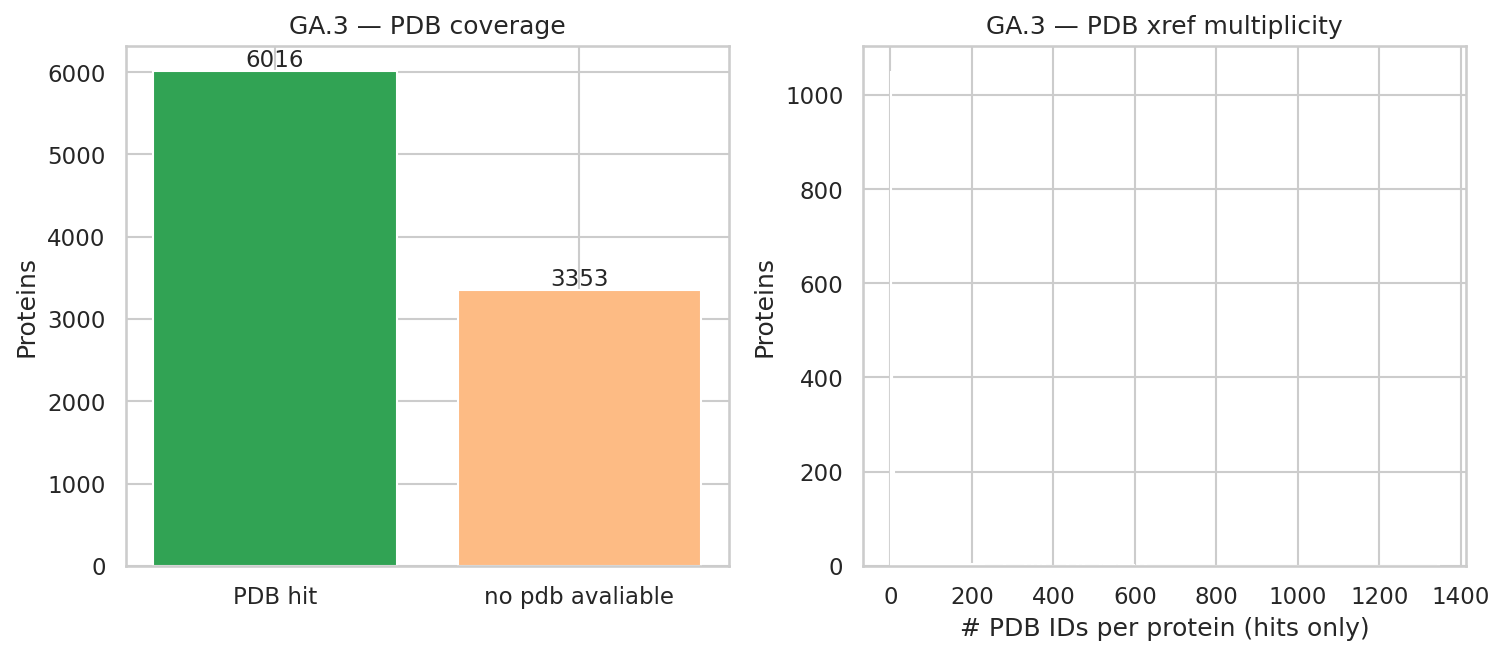

A4D126 4CVH


front /data/ganye/Protein_visualization/plots/structure_3d/4CVH_front.png


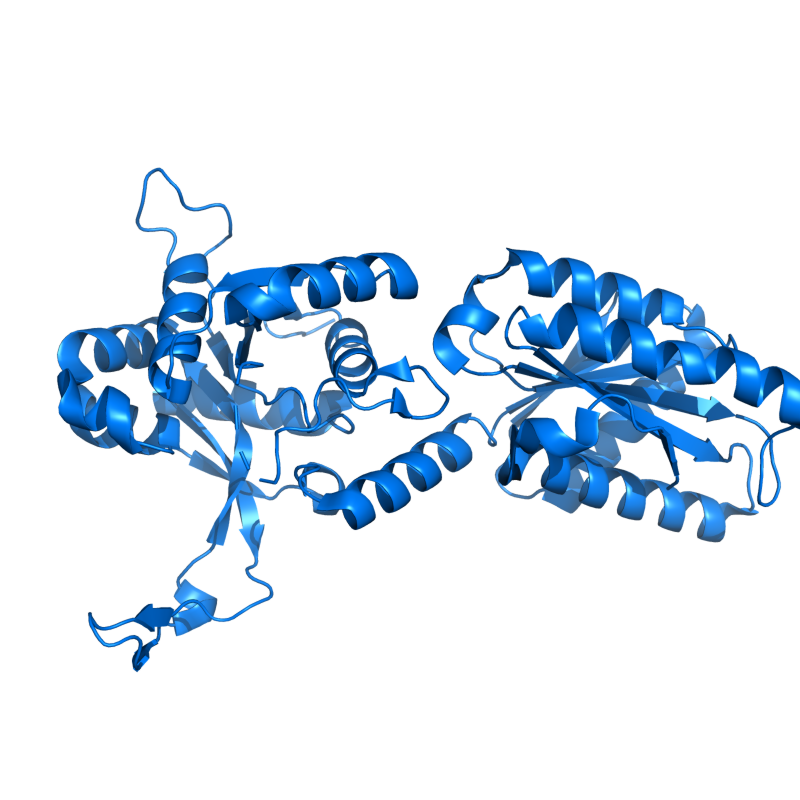

back /data/ganye/Protein_visualization/plots/structure_3d/4CVH_back.png


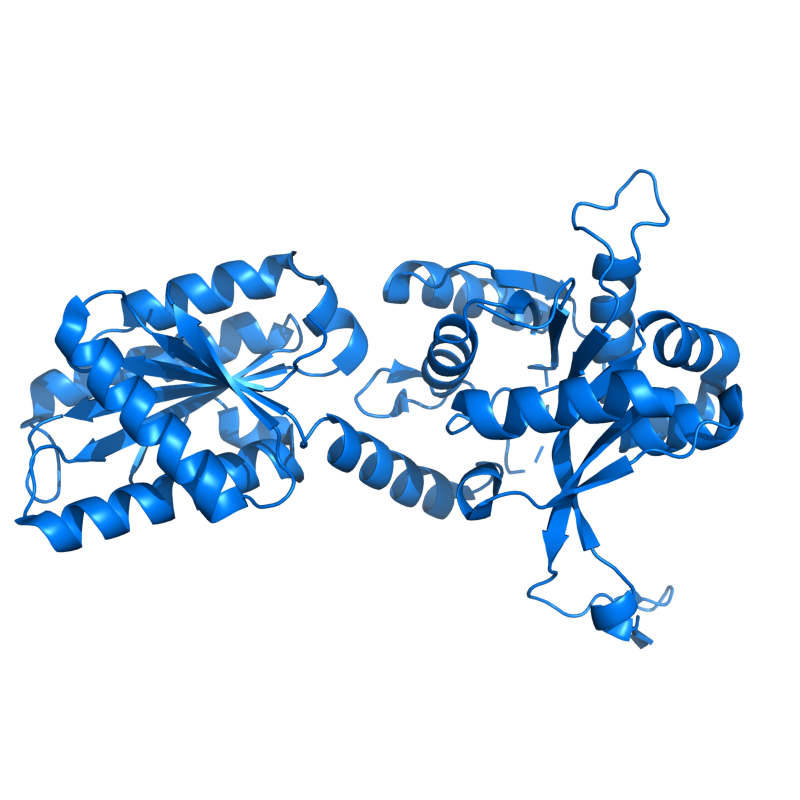

side /data/ganye/Protein_visualization/plots/structure_3d/4CVH_side.png


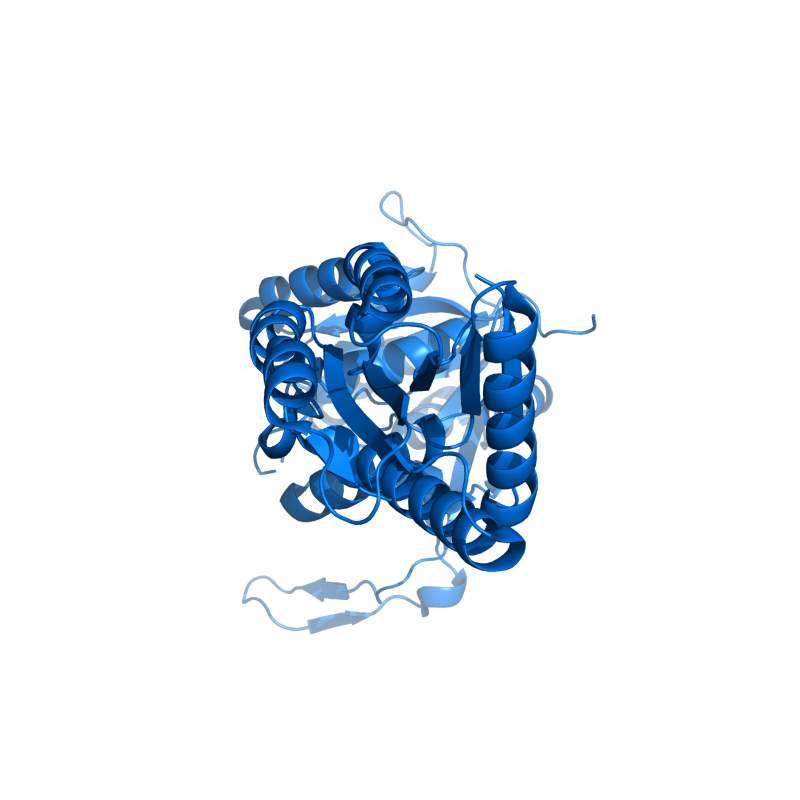

top /data/ganye/Protein_visualization/plots/structure_3d/4CVH_top.png


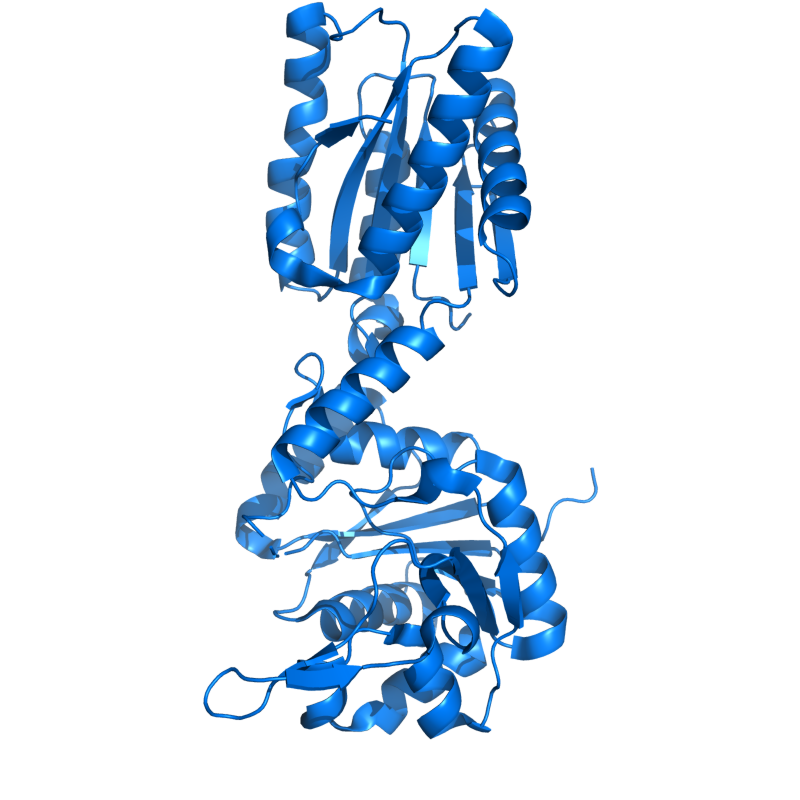

A6NHR9 6MW7


front /data/ganye/Protein_visualization/plots/structure_3d/6MW7_front.png


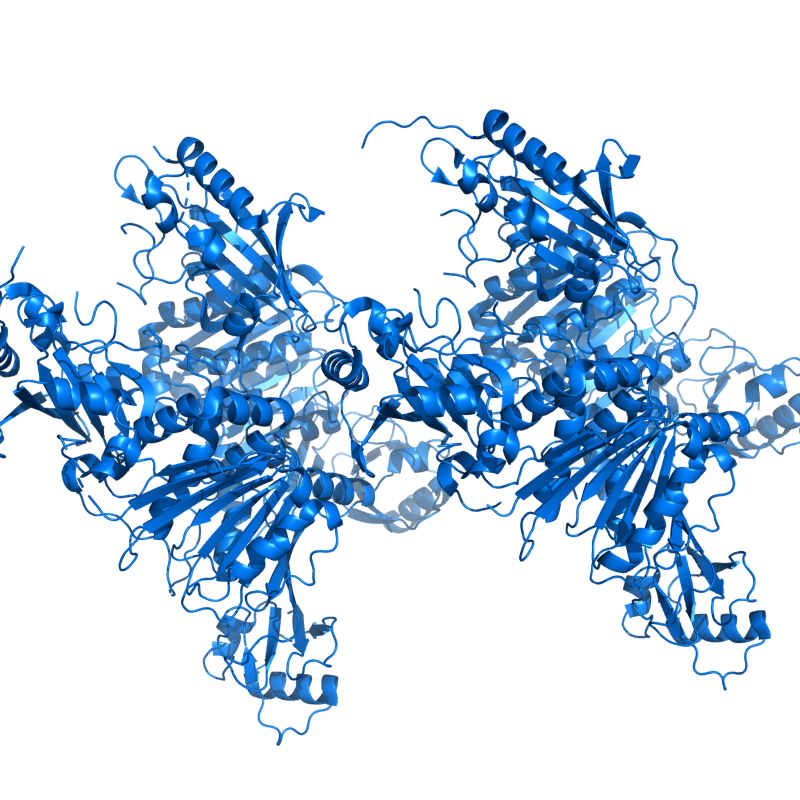

back /data/ganye/Protein_visualization/plots/structure_3d/6MW7_back.png


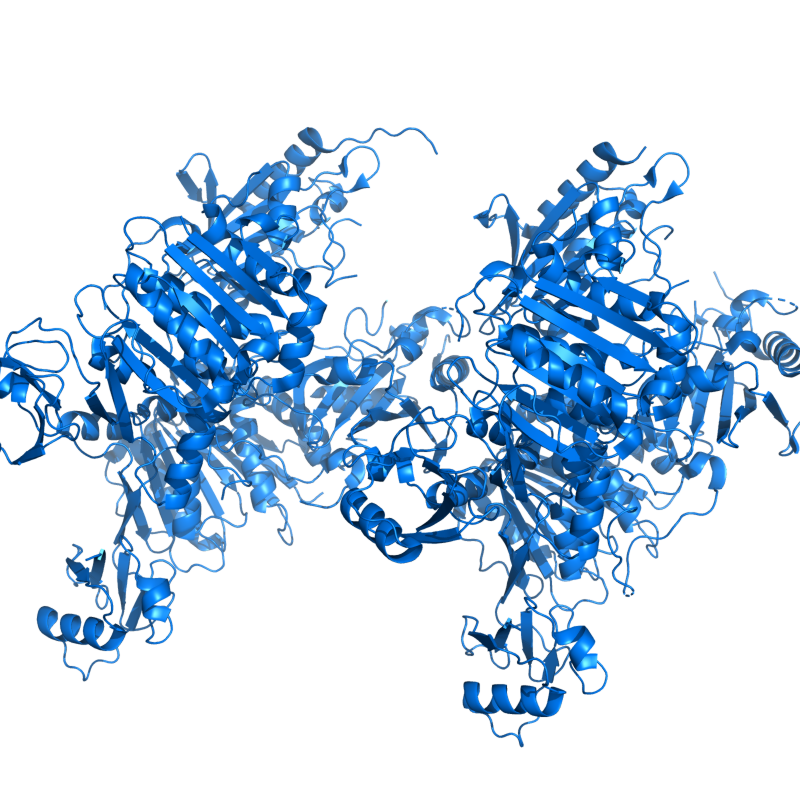

side /data/ganye/Protein_visualization/plots/structure_3d/6MW7_side.png


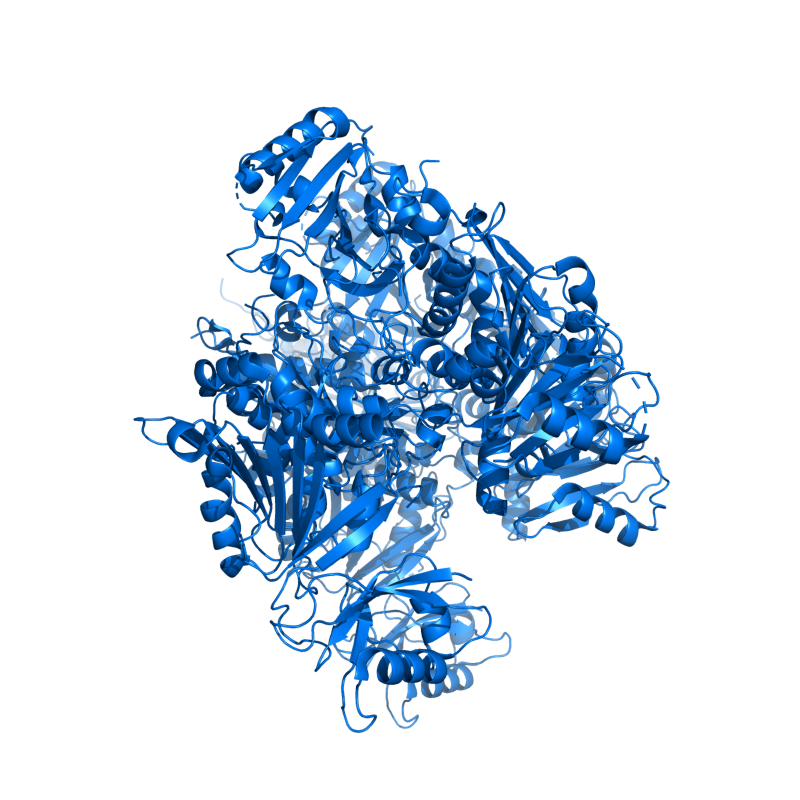

top /data/ganye/Protein_visualization/plots/structure_3d/6MW7_top.png


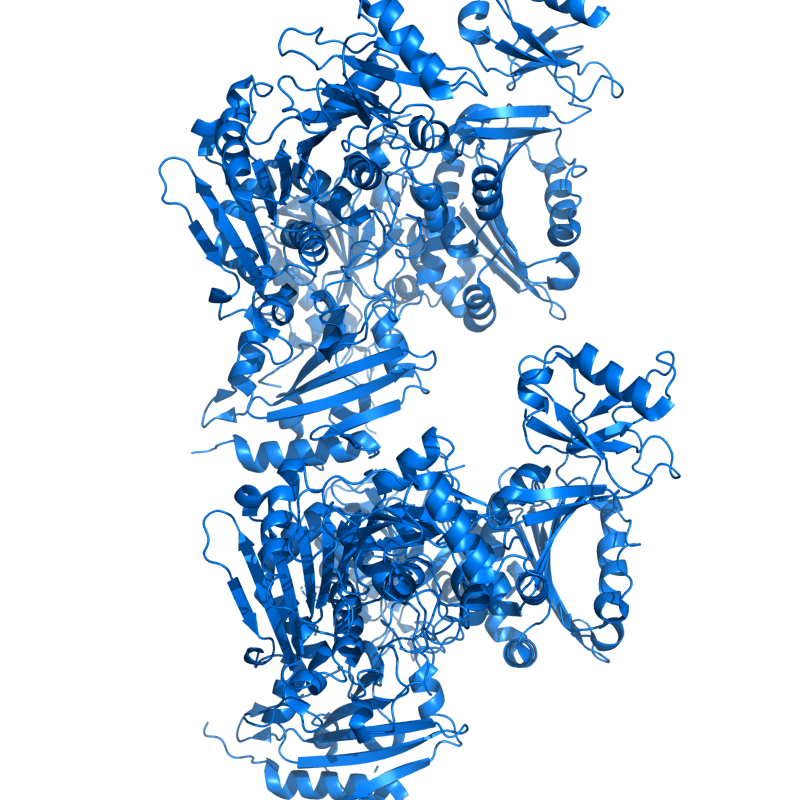

O00148 8IJU


front /data/ganye/Protein_visualization/plots/structure_3d/8IJU_front.png


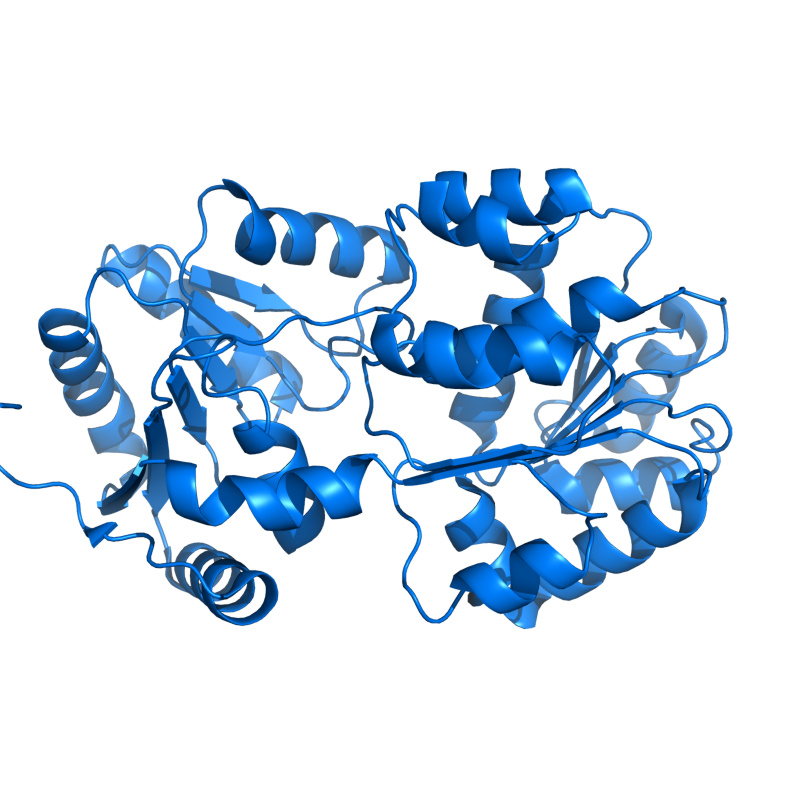

back /data/ganye/Protein_visualization/plots/structure_3d/8IJU_back.png


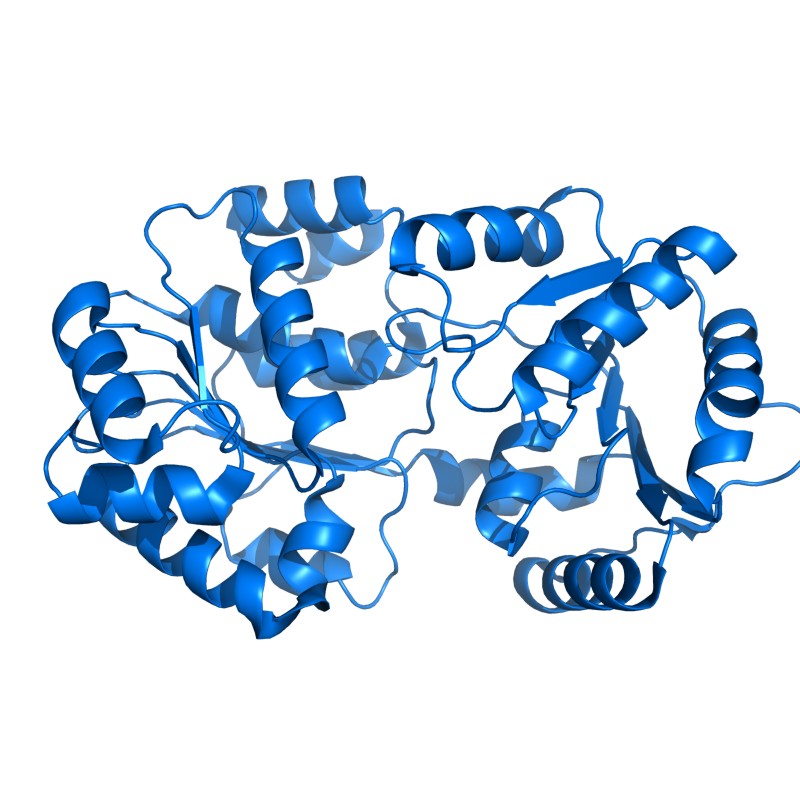

side /data/ganye/Protein_visualization/plots/structure_3d/8IJU_side.png


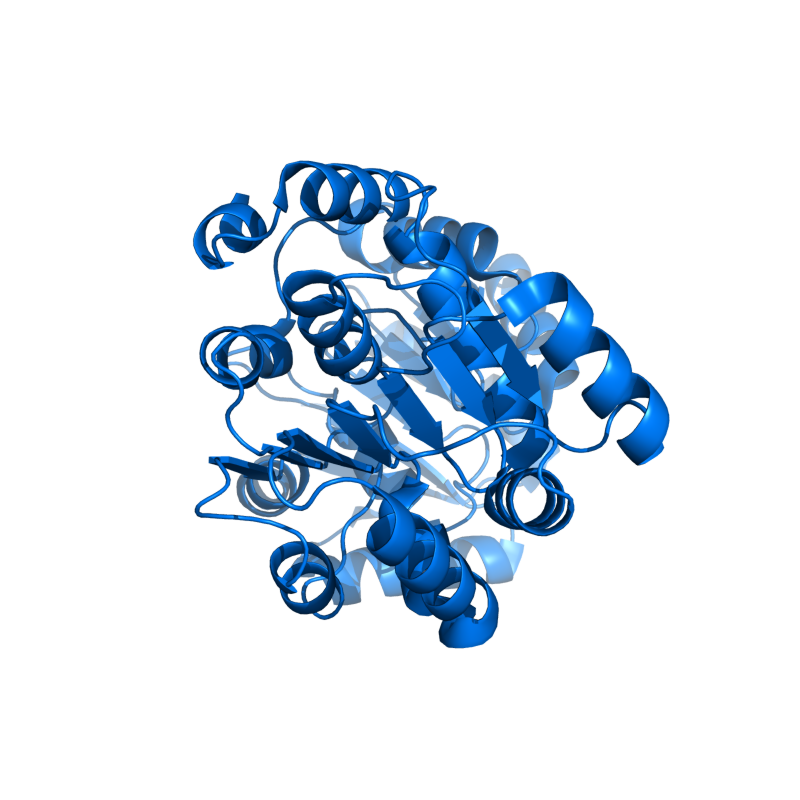

top /data/ganye/Protein_visualization/plots/structure_3d/8IJU_top.png


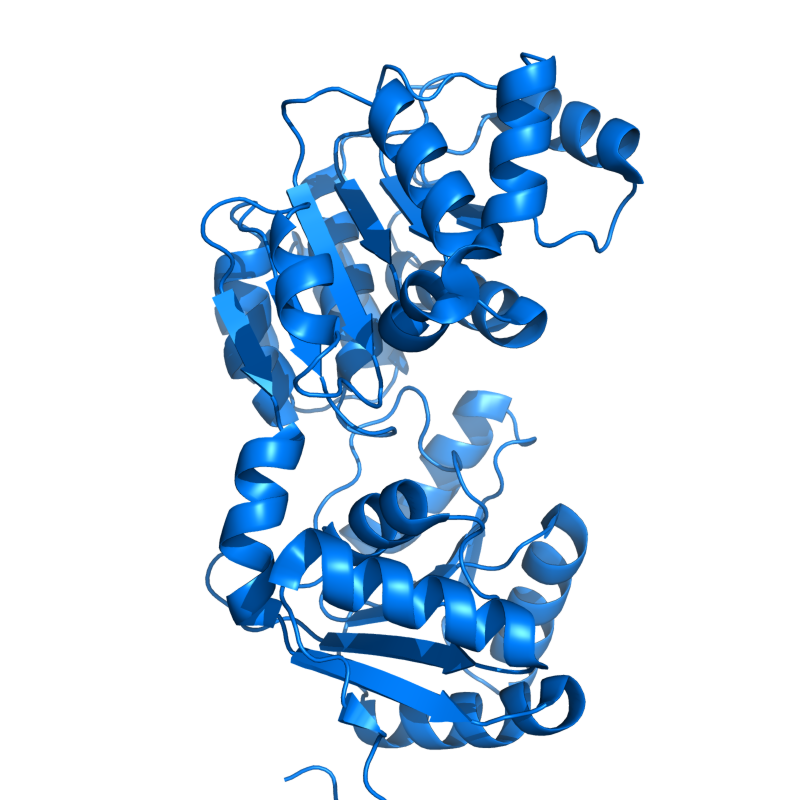

O00154 2QQ2


front /data/ganye/Protein_visualization/plots/structure_3d/2QQ2_front.png


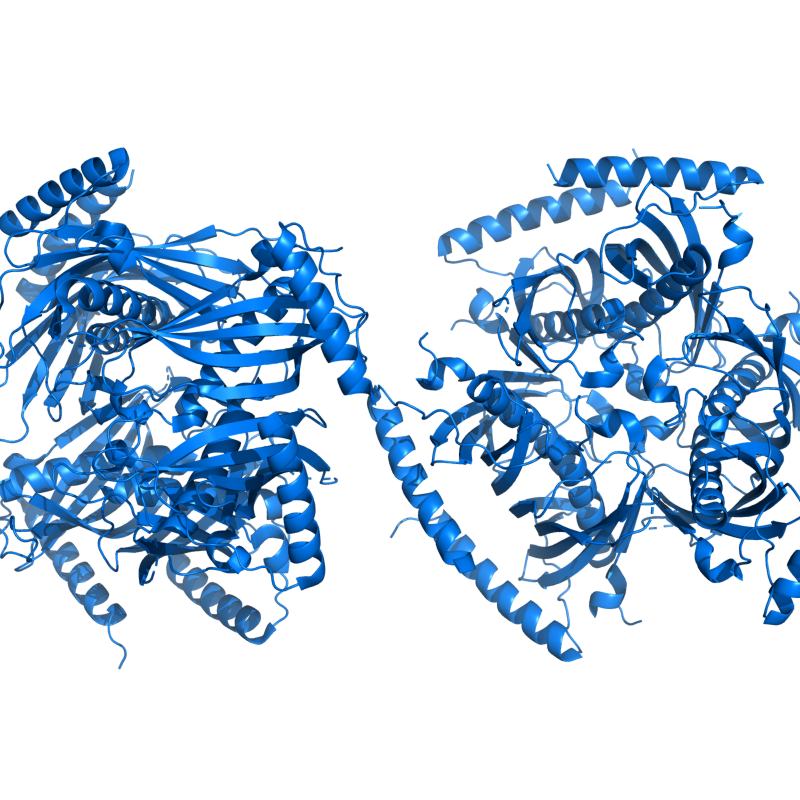

back /data/ganye/Protein_visualization/plots/structure_3d/2QQ2_back.png


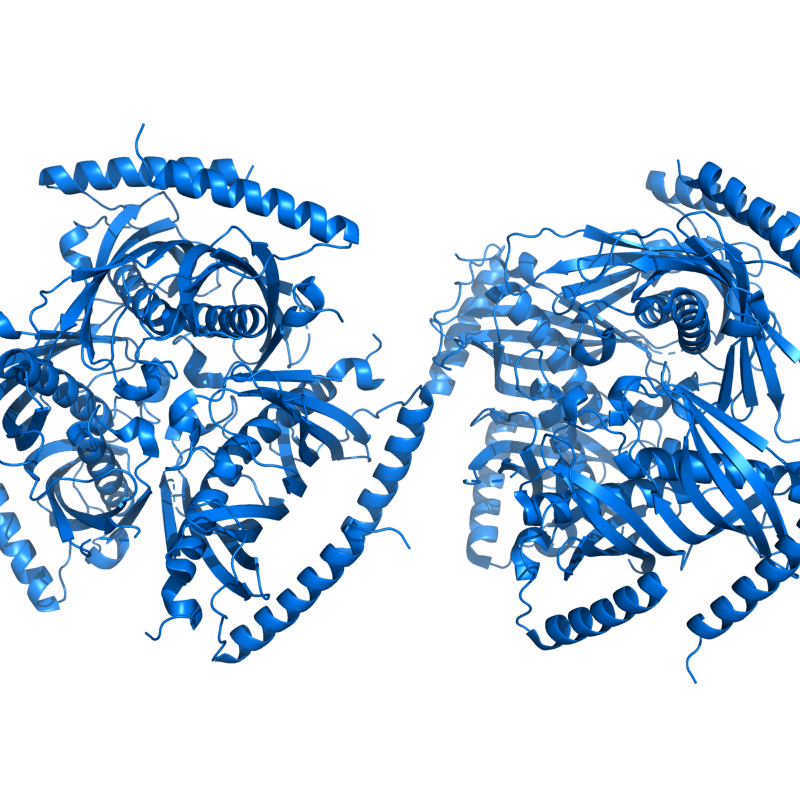

side /data/ganye/Protein_visualization/plots/structure_3d/2QQ2_side.png


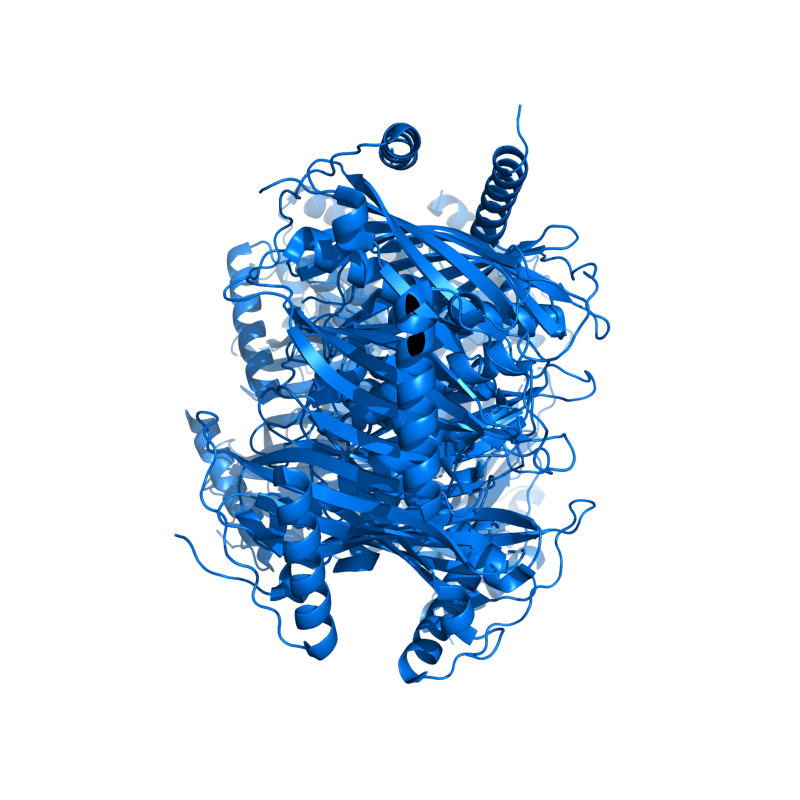

top /data/ganye/Protein_visualization/plots/structure_3d/2QQ2_top.png


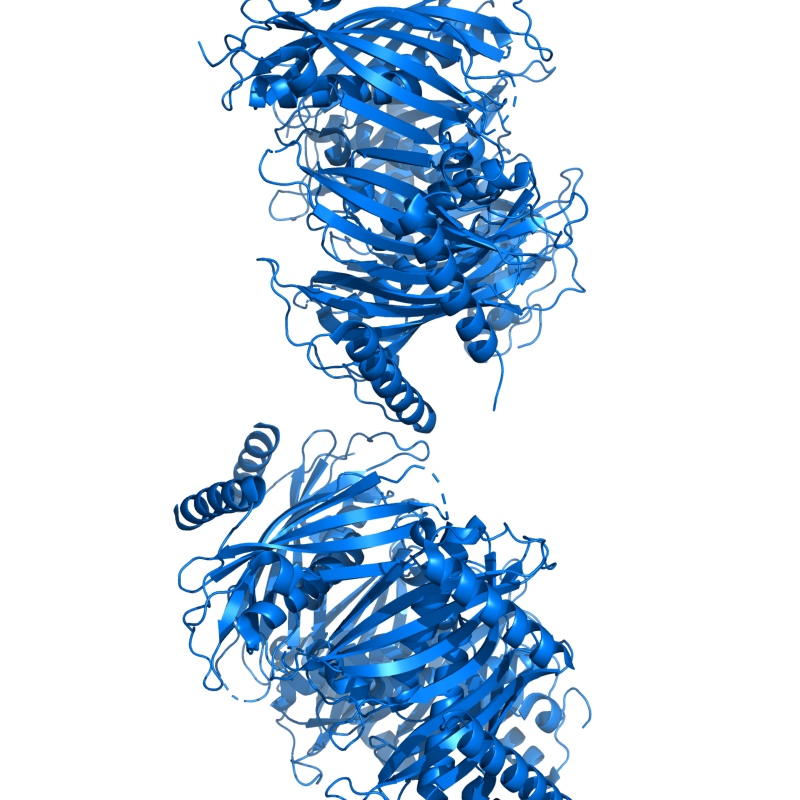

In [41]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

OUT = Path("/data/ganye/Protein_visualization")
S3D = OUT / "plots" / "structure_3d"
renders = pd.read_csv(OUT / "ga3_structure_3d_renders.csv")
print(renders[["Protein ID", "pdb_id"]])
# Coverage summary figure (still useful)
display(Image(filename=str(OUT / "plots" / "ga3_pdb_coverage.png")))
# Multi-view 3D for each example PDB
for _, r in renders.iterrows():
    print(r["Protein ID"], r["pdb_id"])
    for view in ["front", "back", "side", "top"]:
        p = S3D / f'{r["pdb_id"]}_{view}.png'
        print(view, p)
        display(Image(filename=str(p)))


#### Obtain → CSV (reference implementation)

The full 9369-protein run used UniProt batch + on-disk cache (`cache/uniprot_batch_cache.json`). Sketch of the per-accession rule:

```python
NO_PDB = "no pdb avaliable"
# pdbs = [... PDB ids from UniProt xref ...]
if pdbs:
    pdb_id, pdb_ids = pdbs[0], ";".join(pdbs)
    pdb_url = f"https://www.rcsb.org/structure/{pdb_id}"
else:
    pdb_id = pdb_ids = pdb_url = NO_PDB
```


### GA.4 — Sequence (full AA string; no sequence plots)

#### What it is
The canonical amino-acid string for the UniProt accession (`ACDEFGHIKLMNPQRSTVWY…`). FragPipe’s `combined_protein.tsv` exposes **`Protein Length`** (int) but **not** the sequence characters. Sequences were batched from UniProt into `proteins_with_sequences.csv` (`Protein ID`, `Gene`, `Protein Length`, `Sequence`, …).

#### Deliverable (this section)
No histogram / coverage plots. Instead: **pandas-load the sequence CSV and print one randomly selected protein’s entire sequence** (reproducible seed in the code cell). Rows without a sequence string are excluded from the draw.

**Shown example:** Protein ID **`Q8WUX2`** (Gene `CHAC2`, length 184).


In [42]:
from pathlib import Path
import random
import pandas as pd

OUT = Path("/data/ganye/Protein_visualization")
seq_df = pd.read_csv(OUT / "proteins_with_sequences.csv", low_memory=False)
print("proteins_with_sequences.csv", seq_df.shape)
print("columns:", list(seq_df.columns))
print(seq_df.dtypes)
print(seq_df.head())

usable = seq_df[seq_df["Sequence"].fillna("").str.len() > 0].reset_index(drop=True)
rng = random.Random(20260930)  # reproducible
row = usable.iloc[rng.randrange(len(usable))]
pid, gene, sequence = row["Protein ID"], row.get("Gene", ""), row["Sequence"]
print("\n=== Random protein (full sequence) ===")
print("Protein ID:", pid)
print("Gene:", gene)
print("length:", len(sequence))
print(sequence)

tsv = pd.read_csv(OUT / "combined_protein.tsv", sep="\t", usecols=["Protein ID", "Gene", "Protein Length"], low_memory=False)
print("\nFragPipe row:")
print(tsv[tsv["Protein ID"] == pid])


proteins_with_sequences.csv (9369, 5)
columns: ['Protein ID', 'Gene', 'uniprot_gene', 'Protein Length', 'Sequence']
Protein ID        object
Gene              object
uniprot_gene      object
Protein Length     int64
Sequence          object
dtype: object
   Protein ID  ...                                           Sequence
0  A0A024R1R8  ...  MSSHEGGKKKALKQPKKQAKEMDEEEKAFKQKQKEEQKKLEVLKAK...
1  A0A0B4J2F0  ...  MFRRLTFAQLLFATVLGIAGGVYIFQPVFEQYAKDQKELKEKMQLV...
2  A0A0J9YX57  ...  MPRGQKSKLRARGKRRETHDQPQGLTGPQATAEKQEESRSSSSSSA...
3  A0A2R8Y4L2  ...  MSKSESPKEPEQLRKLFIGGLSFETTDESLRSHFEQWGTLTDCVVM...
4  A0A7I2V3R4  ...  MAAPASDSGGSQQSPSSSPGSREGAGVAAKGAPDCGDAGARDAAET...

[5 rows x 5 columns]

=== Random protein (full sequence) ===
Protein ID: Q8WUX2
Gene: CHAC2
length: 184
MWVFGYGSLIWKVDFPYQDKLVGYITNYSRRFWQGSTDHRGVPGKPGRVVTLVEDPAGCVWGVAYRLPVGKEEEVKAYLDFREKGGYRTTTVIFYPKDPTTKPFSVLLYIGTCDNPDYLGPAPLEDIAEQIFNAAGPSGRNTEYLFELANSIRNLVPEEADEHLFALEKLVKERLEGKQNLNCI

FragPipe row:
     Protein ID   Ge

#### Note on plots
Sequence **plots are intentionally omitted** (Henry). Use the pandas cell above to inspect full AA strings. For length sanity checks, compare `len(Sequence)` to FragPipe `Protein Length` without plotting.


In [43]:
# GA.4: no sequence plots (by design)
print("Skipping sequence length histogram — full sequence printed in the previous cell.")
print("Random Protein ID shown above.")


Skipping sequence length histogram — full sequence printed in the previous cell.
Random Protein ID shown above.


### GA.5 — PPI (STRING)

#### What it is
Database edges “protein A associated with protein B” with a STRING combined score (typically threshold 400 ≈ medium confidence). **Not** computed from the MS intensities.

#### Organism caveat (critical for HYE)
STRING queries are **species-scoped**. This table mixes human / yeast / E. coli. Map with taxids such as:
- human `9606`
- *S. cerevisiae* `4932` (note: strain-level `559292` can 400 on some STRING endpoints)
- *E. coli* K12 `83333`

#### Outputs
- `ppi_string_id_map.csv` — every `Protein ID` → `species` + `stringId`
- `ppi_string_edges.csv` — edges from chunked `/network` calls (score ≥ 400)

Chunked networks recover edges **within** identifier chunks; they are not a single all-vs-all graph of 9k nodes. For viewer prototypes that is usually enough to seed neighborhoods.


In [7]:
# GA.5 — load STRING map + edges; show key columns
idmap = pd.read_csv(OUT / "ppi_string_id_map.csv")
edges = pd.read_csv(OUT / "ppi_string_edges.csv", low_memory=False)
print("ppi_string_id_map", idmap.shape, list(idmap.columns))
print(idmap.dtypes)
print("mapped:", int(idmap["stringId"].fillna("").ne("").sum()))
print(idmap.groupby("species").size())
print("\nppi_string_edges", edges.shape)
print("edge columns:", list(edges.columns)[:20], "...")
# show a compact edge preview if columns exist
cols = [c for c in ["Protein_A", "Protein_B", "preferredName_A", "preferredName_B", "score", "species"] if c in edges.columns]
print(edges[cols].head(8) if cols else edges.head(8))
idmap.head(8)


ppi_string_id_map (9369, 3) ['Protein ID', 'species', 'stringId']
Protein ID    object
species        int64
stringId      object
dtype: object
mapped: 9338
species
4932     3099
9606     5058
83333    1212
dtype: int64

ppi_string_edges (11132, 16)
edge columns: ['Protein_A', 'Protein_B', 'ascore', 'dscore', 'escore', 'fscore', 'ncbiTaxonId', 'nscore', 'preferredName_A', 'preferredName_B', 'pscore', 'score', 'species', 'stringId_A', 'stringId_B', 'tscore'] ...
  Protein_A Protein_B preferredName_A preferredName_B  score  species
0    A4D1E9    A6NJ78         GTPBP10         METTL15  0.602     9606
1    O00148    C9J7I0          DDX39A           UMAD1  0.487     9606
2    O00161    O00159          SNAP23           MYO1C  0.529     9606
3    A2RRP1    O00139            NBAS           KIF2A  0.516     9606
4    A5D8V6    C9J7I0          VPS37C           UMAD1  0.403     9606
5    A5YKK6    A1L020           CNOT1           MEX3A  0.817     9606
6    A4D1P6    A6NDU8           WDR91        

,Protein ID,species,stringId
0,A0A024R1R8,9606,9606.ENSP00000491117
1,A0A0B4J2F0,9606,9606.ENSP00000484893
2,A0A0J9YX57,9606,9606.ENSP00000488257
3,A0A2R8Y4L2,9606,9606.ENSP00000493805
4,A0A7I2V3R4,9606,NaN
5,A0AVT1,9606,9606.ENSP00000313454
6,A0FGR8,9606,9606.ENSP00000499020
7,A0JLT2,9606,9606.ENSP00000498791


#### How to plot GA.5 from the CSVs

**Load:** `ppi_string_edges.csv` (edges) and optionally `ppi_string_id_map.csv`.

**Degree histogram:** concatenate endpoint columns (`Protein_A`/`Protein_B`, fallback `preferredName_*`), `value_counts()`, histogram.

**Scores:** histogram of `score` (STRING combined score; export used `required_score=400`).

**Network sketch:** `networkx` spring layout on a neighborhood of a high-degree node (full 9k×9k graph is not what chunked STRING export represents).


GA.5 PPI plots from ppi_string_edges.csv\n


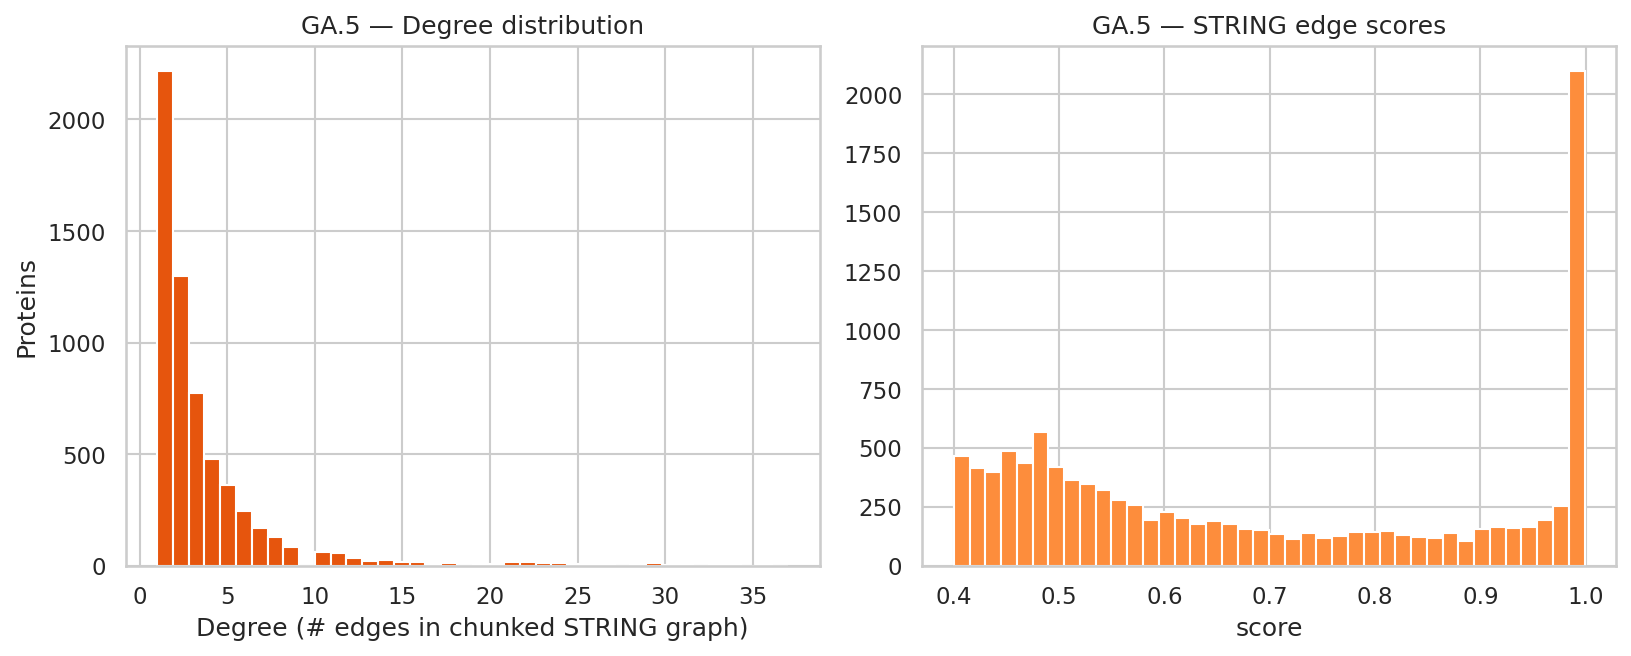

saved /data/ganye/Protein_visualization/plots/ga5_ppi_degree_and_scores.png


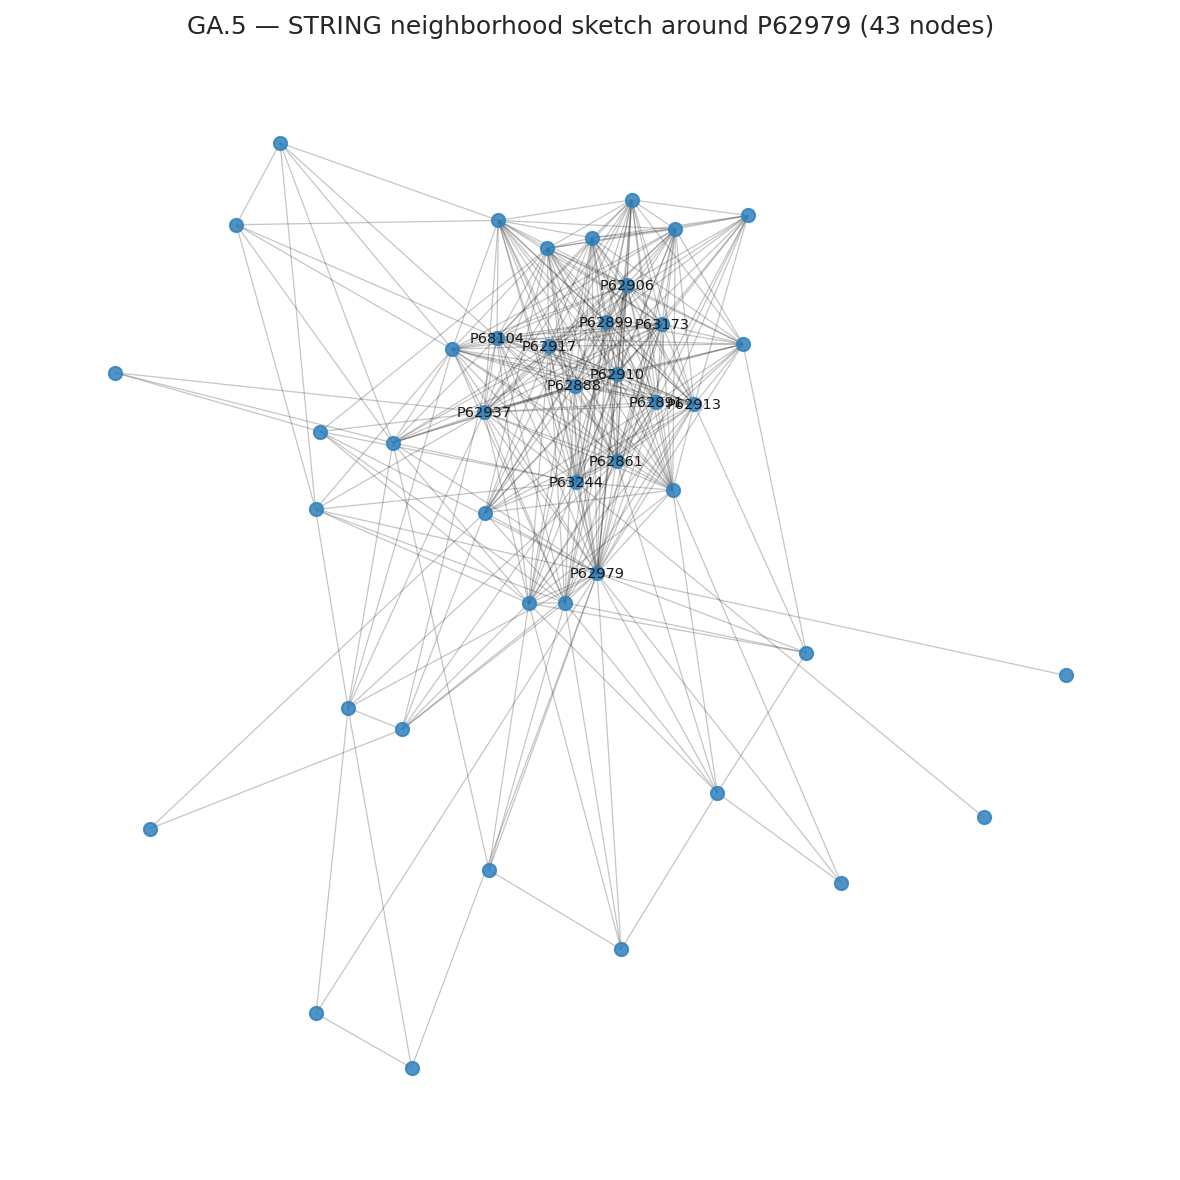

saved /data/ganye/Protein_visualization/plots/ga5_ppi_network_neighborhood.png


In [25]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

OUT = Path("/data/ganye/Protein_visualization")
PLOTS = OUT / "plots"
edges = pd.read_csv(OUT / "ppi_string_edges.csv", low_memory=False)
print("edges", edges.shape)
print("columns sample:", list(edges.columns)[:15])
print(edges.head())

A = edges["Protein_A"].fillna("").astype(str)
B = edges["Protein_B"].fillna("").astype(str)
if (A == "").all() and "preferredName_A" in edges.columns:
    A, B = edges["preferredName_A"].astype(str), edges["preferredName_B"].astype(str)
deg = pd.concat([A, B]); deg = deg[deg.ne("") & deg.ne("nan")].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(deg.values, bins=40, color="#e6550d", edgecolor="white")
axes[0].set_title("GA.5 — degree"); axes[0].set_xlabel("Degree")
sc = "score" if "score" in edges.columns else next((c for c in edges.columns if "score" in c.lower()), None)
if sc:
    axes[1].hist(edges[sc].dropna(), bins=40, color="#fd8d3c", edgecolor="white")
    axes[1].set_title(f"GA.5 — {sc}")
fig.savefig(PLOTS / "ga5_ppi_degree_and_scores.png", dpi=150, bbox_inches="tight"); plt.show()

G = nx.Graph()
for _, r in edges.iterrows():
    a = str(r.get("Protein_A") or r.get("preferredName_A") or "")
    b = str(r.get("Protein_B") or r.get("preferredName_B") or "")
    if a not in ("", "nan") and b not in ("", "nan"):
        G.add_edge(a, b)
top = sorted(G.degree, key=lambda x: x[1], reverse=True)[0][0]
nodes = {top} | set(G.neighbors(top))
extra = set()
for n in list(nodes)[:20]:
    extra |= set(list(G.neighbors(n))[:5])
sub = G.subgraph(list(nodes | extra)[:80]).copy()
pos = nx.spring_layout(sub, seed=42, k=0.35)
fig, ax = plt.subplots(figsize=(8, 8))
nx.draw_networkx_nodes(sub, pos, node_size=40, node_color="#3182bd", alpha=0.85, ax=ax)
nx.draw_networkx_edges(sub, pos, alpha=0.25, width=0.6, ax=ax)
deg_sub = dict(sub.degree)
cut = sorted(deg_sub.values(), reverse=True)[min(8, len(deg_sub)-1)]
nx.draw_networkx_labels(sub, pos, labels={n: n for n,d in deg_sub.items() if d >= cut}, font_size=7, ax=ax)
ax.set_axis_off(); ax.set_title(f"GA.5 — neighborhood around {top}")
fig.savefig(PLOTS / "ga5_ppi_network_neighborhood.png", dpi=150, bbox_inches="tight"); plt.show()


### GA.6 — Spatial mapping

#### What it is
Subcellular (and related) localization annotations — **not** in FragPipe’s protein TSV. Primary source: UniProt comment type `SUBCELLULAR LOCATION`. Optional tissue/cell links via Human Protein Atlas search URLs (human-centric; for yeast/E. coli prefer UniProt only).

#### Output columns
`Protein ID`, `gene`, `locations` (`; `-joined), `hpa_url`.

#### Caveats
Proteins routinely have **multiple** locations. Empty `locations` means UniProt had no usable SUBCELLULAR LOCATION comment for that accession (or the entry failed to resolve).


In [8]:
# GA.6 — spatial CSV display
spat = pd.read_csv(OUT / "spatial_mapping.csv")
print("spatial_mapping.csv", spat.shape, list(spat.columns))
print(spat.dtypes)
print("with_locations:", int(spat["locations"].fillna("").ne("").sum()))
spat.head(10)


spatial_mapping.csv (9369, 4) ['Protein ID', 'gene', 'locations', 'hpa_url']
Protein ID    object
gene          object
locations     object
hpa_url       object
dtype: object
with_locations: 7840


,Protein ID,gene,locations,hpa_url
0,A0A024R1R8,TMA7B,NaN,https://www.proteinatlas.org/search/TMA7B
1,A0A0B4J2F0,PIGBOS1,Mitochondrion outer membrane,https://www.proteinatlas.org/search/PIGBOS1
2,A0A0J9YX57,MAGEB6B,NaN,https://www.proteinatlas.org/search/MAGEB6B
3,A0A2R8Y4L2,HNRNPA1L3,NaN,https://www.proteinatlas.org/search/HNRNPA1L3
4,A0A7I2V3R4,RNF228,Membrane,https://www.proteinatlas.org/search/RNF228
5,A0AVT1,UBA6,NaN,https://www.proteinatlas.org/search/UBA6
6,A0FGR8,ESYT2,Cell membrane; Endoplasmic reticulum membrane,https://www.proteinatlas.org/search/ESYT2
7,A0JLT2,MED19,Nucleus,https://www.proteinatlas.org/search/MED19
8,A0MZ66,SHTN1,"Perikaryon; Cell projection, axon; Cell projection, growth cone; Cytoplasm, cytoskeleton; Cell projection, filopodium; Cell projection, lamellipodium",https://www.proteinatlas.org/search/SHTN1
9,A1L020,MEX3A,"Cytoplasm; Nucleus; Cytoplasm, P-body",https://www.proteinatlas.org/search/MEX3A


#### How to plot GA.6 from the CSV

**Load:** `spatial_mapping.csv` (`Protein ID`, `gene`, `locations`, `hpa_url`).

**Bar chart:** split `locations` on `;`, strip, `value_counts()`, plot top-N horizontal bars. Proteins are multi-label—counts are annotation incidences, not mutually exclusive protein assignments.


GA.6 location bars from spatial_mapping.csv\n


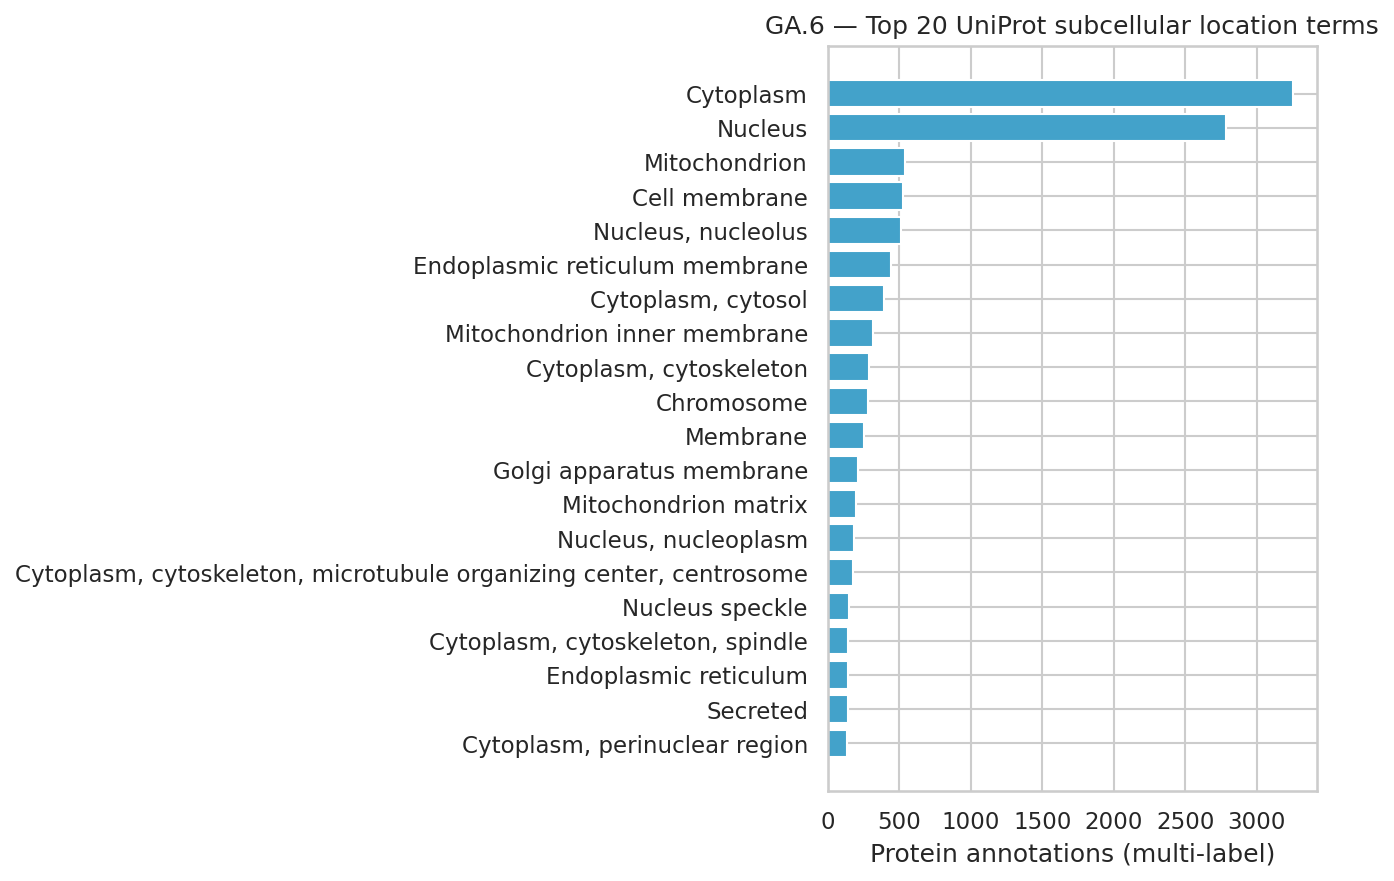

saved /data/ganye/Protein_visualization/plots/ga6_spatial_location_bar.png


In [26]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

OUT = Path("/data/ganye/Protein_visualization")
PLOTS = OUT / "plots"
spat = pd.read_csv(OUT / "spatial_mapping.csv")
print(list(spat.columns)); print(spat.head())
locs = []
for s in spat["locations"].fillna(""):
    for part in str(s).split(";"):
        part = part.strip()
        if part: locs.append(part)
counts = pd.Series(locs).value_counts().head(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(counts.index[::-1], counts.values[::-1], color="#43a2ca")
ax.set_xlabel("Annotation count"); ax.set_title("GA.6 — top UniProt locations")
fig.savefig(PLOTS / "ga6_spatial_location_bar.png", dpi=150, bbox_inches="tight"); plt.show()


## Join everything

Always join on **`Protein ID`**. Example fan-out from `combined_protein.tsv`:

```text
combined_protein.tsv ─Protein ID─► maxlfq_wide.csv / maxlfq_long.csv
                                 ► adjusted_pvalues_wide.csv
                                 ► structure_pdb_index.csv
                                 ► proteins_with_sequences.csv
                                 ► ppi_string_id_map.csv / ppi_string_edges.csv
                                 ► spatial_mapping.csv
```

### Still to do
1. Re-export when a FragPipe run **with** Adjusted P-value columns is available.
2. Decide viewer policy: MaxLFQ `0` → NA.
3. Optionally densify STRING beyond chunked neighborhoods if a global graph is required.


In [42]:
from pathlib import Path
import random
import pandas as pd

OUT = Path("/data/ganye/Protein_visualization")
seq_df = pd.read_csv(OUT / "proteins_with_sequences.csv", low_memory=False)
print("proteins_with_sequences.csv", seq_df.shape)
print("columns:", list(seq_df.columns))
print(seq_df.dtypes)
print(seq_df.head())

usable = seq_df[seq_df["Sequence"].fillna("").str.len() > 0].reset_index(drop=True)
rng = random.Random(20260930)  # reproducible
row = usable.iloc[rng.randrange(len(usable))]
pid, gene, sequence = row["Protein ID"], row.get("Gene", ""), row["Sequence"]
print("\n=== Random protein (full sequence) ===")
print("Protein ID:", pid)
print("Gene:", gene)
print("length:", len(sequence))
print(sequence)

# Also show FragPipe length for the same ID if present
tsv = pd.read_csv(OUT / "combined_protein.tsv", sep="\t", usecols=["Protein ID", "Gene", "Protein Length"], low_memory=False)
print("\nFragPipe row:")
print(tsv[tsv["Protein ID"] == pid])


proteins_with_sequences.csv (9369, 5)
columns: ['Protein ID', 'Gene', 'uniprot_gene', 'Protein Length', 'Sequence']
Protein ID        object
Gene              object
uniprot_gene      object
Protein Length     int64
Sequence          object
dtype: object
   Protein ID  ...                                           Sequence
0  A0A024R1R8  ...  MSSHEGGKKKALKQPKKQAKEMDEEEKAFKQKQKEEQKKLEVLKAK...
1  A0A0B4J2F0  ...  MFRRLTFAQLLFATVLGIAGGVYIFQPVFEQYAKDQKELKEKMQLV...
2  A0A0J9YX57  ...  MPRGQKSKLRARGKRRETHDQPQGLTGPQATAEKQEESRSSSSSSA...
3  A0A2R8Y4L2  ...  MSKSESPKEPEQLRKLFIGGLSFETTDESLRSHFEQWGTLTDCVVM...
4  A0A7I2V3R4  ...  MAAPASDSGGSQQSPSSSPGSREGAGVAAKGAPDCGDAGARDAAET...

[5 rows x 5 columns]

=== Random protein (full sequence) ===
Protein ID: Q8WUX2
Gene: CHAC2
length: 184
MWVFGYGSLIWKVDFPYQDKLVGYITNYSRRFWQGSTDHRGVPGKPGRVVTLVEDPAGCVWGVAYRLPVGKEEEVKAYLDFREKGGYRTTTVIFYPKDPTTKPFSVLLYIGTCDNPDYLGPAPLEDIAEQIFNAAGPSGRNTEYLFELANSIRNLVPEEADEHLFALEKLVKERLEGKQNLNCI

FragPipe row:
     Protein ID   Ge